
# EyeMovementTrajectoryAlternatingBackground — the population code

Protocol-specific analysis. `demos/meaAnalysisMain.ipynb` is the shared front half — it finds datasets and builds a pipeline, then stops before conditions get interpreted, because that is where protocols stop resembling each other. This picks up there and runs standalone: §1 searches every matching dataset, and you select one by changing only `ENTRY`. A compatible `pipeline` already in the kernel is reused rather than rebuilt.

**The protocol**: a natural image is swept across the retina along a simulated eye-movement trajectory. Two things alternate across epochs — the **image**, and a **background scale** that multiplies the image's own mean intensity by 0.1 or 10. Each epoch is 30 s of that adapting background with nothing on the screen, then 30 s of movie. The image, and therefore the movie's mean luminance, is the same under both histories: what differs is only what the retina had been looking at for the 30 s before.

**The repeat is the design.** The trajectory is generated once and then written down twice — `xTraj = [xTraj, xTraj]` in the `.m` — so those 30 s are **two identical presentations of one 15 s movie**. That turns "has the representation recovered?" into a comparison the stimulus controls by construction: the same movie, seen once by a retina that has just been stepped and once by a retina that has had the movie's own luminance for a full cycle. It is worth more than the three repeats per condition the block has, because it holds the stimulus fixed while letting adaptation state run.

Three rules the section order encodes:

- **Epochs first, then cells** (§3 before §4). The other order scores every cell against a stretch of block you were going to discard, which reports a property of the block as a property of each cell.
- **Every stimulus value comes from the recorded epochs**, never from the `.m` defaults — including, in §5, where the cycles actually begin.
- **Never pool images.** A different image is a different movie. Every measurement below is computed per image and only then summarised across them.

The appendix at the end is the archive, visual-QC and single-cell workflow this notebook used to be, kept as it was.

## 1. Search and choose the dataset

The first cell searches the database for this protocol and resolves each row to the nearest loadable typed noise chunk, exactly like §4 of `meaAnalysisMain.ipynb`. The database's raw sorting label remains visible as `chunk_name`; `analysis_chunk_name` is the actual Vision directory that will be loaded.

Run the search, inspect the indexed table, then change only `ENTRY` in the next cell. `EXP_NAME`, `DATAFILE_NAME`, `ANALYSIS_CHUNK`, and the full dotted `PROTOCOL_NAME` are all read from that row.


In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROTOCOL_SEARCH = 'EyeMovementTrajectoryAlternatingBackground'
MAIN_TYPES = ['OnP', 'OffP', 'OnM', 'OffM']

exp_search = ra.find_available_datasets(PROTOCOL_SEARCH)
exp_search = ra.add_analysis_chunk_columns(exp_search)
SEARCH_COLS = ['exp_name', 'datafile_name', 'analysis_chunk_name',
               'ss_version', 'chunk_distance_min', 'NDF', 'group_label',
               'chunk_name']

print(f'{len(exp_search)} blocks across {exp_search["exp_name"].nunique()} '
      f'dates; {(exp_search["ss_version"] != "not found").sum()} have a '
      'loadable typed noise chunk')
display(exp_search[SEARCH_COLS])



Found 1 protocols matching "eyemovementtrajectoryalternatingbackground":
['edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground']

Found 22 experiments, 31 epoch blocks.

26 blocks across 17 dates; 25 have a loadable typed noise chunk


,exp_name,datafile_name,analysis_chunk_name,ss_version,chunk_distance_min,NDF,group_label,chunk_name
0,20220823C,data035,chunk5,kilosort2,29.216667,NaN,Eye movement trajectory alt background rod,chunk5
1,20221101C,data018,chunk2,kilosort2,147.600000,0.0,Eye movement alt background,chunk2
2,20221101C,data025,chunk2,kilosort2,209.866667,0.0,Eye movement alt background,chunk3
3,20221101C,data032,chunk2,kilosort2,253.450000,0.0,Eye movement alt background,chunk3
4,20221123C,data027,chunk4,kilosort2,53.700000,2.0,CC eye movement alt background ndf2.0,chunk4
5,20230214C,data018,chunk2,kilosort2,25.583333,3.0,eye movement alt background ndf 3.0,chunk2
6,20230313C,data017,chunk2,kilosort2,14.150000,3.0,eye movement alt background ndf 3.0,chunk2
7,20230313C,data019,chunk2,kilosort2,61.483333,3.0,Var Mean Drift Grating ndf 3.0,chunk2
8,20230502C,data018,chunk2,kilosort2,189.950000,2.0,ndf 2.0 eye movement alt background,chunk2
9,20230725C,data036,chunk3,kilosort2,130.083333,2.0,ndf 2 eye movement alt background,chunk4


### Build the selected pipeline

Change only `ENTRY`, using a row whose `ss_version` is not `not found`. The resolved experiment, protocol datafile, analysis chunk, and protocol class name are printed before the pipeline is built.


In [2]:
ENTRY = 23   # <-- EDIT ME: row index from the search table above
# 0, on cells only, 1&2& 3 nicer off, barely any on cells; 4 seems decent mosaic, 5 data018 missing in SSD; 6 is not good across; 7 might have some good onM' 
# 8 decent, 9 bettr midgets some onP; 10 better off resp.  11, only 5 epochs; 12, off resp only, 13 low firing; 14 off M seems okay, 15 better off; 16 better off, some onM
# 17 & 18 not in SSD,  19 good off, ok on; 20-21 good; 22 seems inconsistent across cells; 23 good; 24 bad; 25 not in SSD

entry          = exp_search.loc[ENTRY]
EXP_NAME       = entry['exp_name']
DATAFILE_NAME  = entry['datafile_name']
ANALYSIS_CHUNK = entry['analysis_chunk_name']
PROTOCOL_NAME  = entry['protocol_name']

if entry['ss_version'] == 'not found' or not ANALYSIS_CHUNK:
    raise ValueError(f'ENTRY {ENTRY} has no loadable typed noise chunk; pick another row')

print(f'{EXP_NAME} / {DATAFILE_NAME}')
print(f'noise chunk: {ANALYSIS_CHUNK} ({entry["ss_version"]})')
print(f'protocol: {PROTOCOL_NAME}\n')

EYE_OUTPUT_ROOT = Path('/Volumes/ChrisProSSD/retinanalysis_output')
if not EYE_OUTPUT_ROOT.is_dir():
    raise FileNotFoundError(
        f'Expected mounted proSSD output folder: {EYE_OUTPUT_ROOT}')
print(f'Eye-movement analysis and saved plots -> {EYE_OUTPUT_ROOT}')

# Reuse a pristine pipeline only when every selected dataset component agrees.
_existing = globals().get('pipeline')
if (_existing is not None
        and getattr(_existing.resp, 'datafile_name', None) == DATAFILE_NAME
        and _existing.analysis_chunk.exp_name == EXP_NAME
        and _existing.analysis_chunk.chunk_name == ANALYSIS_CHUNK
        and not hasattr(_existing.resp, 'dedup_log')):
    pipeline = _existing
    print(f'Reusing the pipeline already in this kernel: '
          f'{EXP_NAME}/{DATAFILE_NAME}/{ANALYSIS_CHUNK}')
else:
    pipeline = ra.create_mea_pipeline(
        EXP_NAME, DATAFILE_NAME, analysis_chunk_name=ANALYSIS_CHUNK)

stim_block     = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk


20250924C / data011
noise chunk: chunk3 (kilosort2.5)
protocol: edu.washington.riekelab.turner.protocols.EyeMovementTrajectoryAlternatingBackground

Eye-movement analysis and saved plots -> /Volumes/ChrisProSSD/retinanalysis_output
Initializing StimBlock for 20250924C block 3598
For Rig C 20250924C:
d_display will keep the first one: 59.0
{'disp_type': 'LCR', 'mu_per_pixel': 3.34, 'n_ht': 1140, 'n_wt': 1824, 'mean_frame_rate': 59.94154881781792, 'stage_frame_rate': np.float64(59.0), 'mea_rotation_deg': 90.0}
Using user-specified noise chunk for data011: chunk3.

Initializing ResponseBlock for 20250924C block 3598
If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
Loading V

### Quantitative multichannel spike-sorting inspection

This protocol-level check deliberately runs **before duplicate merging**, while every Vision cell still maps to one Kilosort cluster. It samples two cells per major RGC type from one 30 s raw-data window, constructs an empirical waveform on the target's strongest channels, and compares raw threshold candidates with the multichannel templates of nearby competitors. A raw threshold candidate is proposed from the strongest channel without using Kilosort labels; it is not an independent cell assignment. §2 shows the physical 2-D channel footprint, spikes Kilosort assigned to the labeled cell, and each event's multichannel similarity to the target. It needs the raw binary and Kilosort folder; if those files are not mounted, the notebook reports that and continues.

In [3]:
# Protocol-specific raw-data QC. Keep this before ra.dedup_pipeline.
RUN_SORTING_QC = True
SORT_QC_EPOCH = 0
SORT_QC_WINDOW_S = (0.0, 30.0)
SORT_QC_N_PER_TYPE = 2       # up to 8 cells total
SORT_QC_MIN_SPIKES = 20

SORT_QC_TABLE = pd.DataFrame()
SORT_QC_RESULTS = {}
SORT_QC_EVENTS = {}
SORT_QC_SUMMARY_FIG = None
SORT_QC_DETECTED_SPIKE_FIGURES = {}
SORT_QC_DETECTED_SPIKES_BROWSER = None
SORT_QC_CELL_FIGURES = {}
SORT_QC_CELL_BROWSER = None

if RUN_SORTING_QC:
    _sort_pool = response_block.df_spike_times[[
        'cell_id', 'cell_type', 'spike_times']].copy()
    _sort_pool['n_epoch_spikes'] = _sort_pool['spike_times'].map(
        lambda trains: (len(trains[SORT_QC_EPOCH])
                        if len(trains) > SORT_QC_EPOCH else 0))
    _sort_pool = _sort_pool.query(
        'cell_type in @MAIN_TYPES and n_epoch_spikes >= @SORT_QC_MIN_SPIKES')
    SORT_QC_SAMPLE = ra.sample_cells_by_type(
        _sort_pool, cell_types = MAIN_TYPES,
        n_cells_per_type = SORT_QC_N_PER_TYPE,
        rate_col = 'n_epoch_spikes', sample_strategy = 'random',
        random_seed = 0)
    print('Cells sampled for multichannel sorting QC:')
    display(SORT_QC_SAMPLE)

    try:
        if SORT_QC_SAMPLE.empty:
            raise ValueError('no typed cells have enough spikes in the QC epoch')
        SORT_QC_TABLE, SORT_QC_RESULTS, SORT_QC_RAW = (
            ra.analyze_protocol_sorting_qc(
                response_block, SORT_QC_SAMPLE.cell_id,
                epoch_index = SORT_QC_EPOCH, window_s = SORT_QC_WINDOW_S,
                min_empirical_spikes = SORT_QC_MIN_SPIKES))
    except (FileNotFoundError, OSError, ValueError, IndexError) as exc:
        print(f'Sorting QC unavailable for this run: {type(exc).__name__}: {exc}')
    else:
        SORT_QC_EVENTS = {
            cell_id: result.events.copy()
            for cell_id, result in SORT_QC_RESULTS.items()}
        SORT_QC_SUMMARY_FIG, _ = ra.plot_sorting_qc_summary(SORT_QC_TABLE)
        SORT_QC_CELL_BROWSER = ra.browse_unit_sorting_qc(
            SORT_QC_RESULTS, figure_sink = SORT_QC_CELL_FIGURES)
        plt.show()


Cells sampled for multichannel sorting QC:


,cell_id,cell_type,n_epoch_spikes
0,358,OnP,502
1,667,OnP,986
2,287,OffP,603
3,298,OffP,209
4,27,OnM,1044
5,64,OnM,232
6,532,OffM,781
7,565,OffM,779


Sorting QC unavailable for this run: FileNotFoundError: Raw .bin folder for 20250924C/data011 not found on any configured tier. Raw files are canonical on the NAS (/Volumes/data). Sorting QC is the only thing that needs raw; everything else works without it.
Where it looked:
  DEFAULT: not searched — /Volumes/ChrisNewSSD/single_cell/fred_data/h5 was not mounted when retinanalysis was imported
  SECONDARY: not searched — /Volumes/ChrisNewSSD/single_cell/chris_data/h5 was not mounted when retinanalysis was imported
  PRO_SSD: no 20250924C/data011 under /Volumes/ChrisProSSD/data/raw
  TERTIARY: not searched — /Volumes/data/data/raw was not mounted when retinanalysis was imported
Mounted one of those since? Tiers are discovered at import, so run ra.reload_config() and retry — no kernel restart needed.


### Merge duplicate clusters before cell cleanup

Kilosort can split one physical cell into clusters with near-identical electrical images (EIs). `ra.dedup_pipeline` finds connected groups of those clusters, keeps the typed member with the strongest EI, and unions the spike trains with a short refractory window. This mutates `pipeline.resp` before the epoch summary and silent-cell QC below, so every downstream population analysis counts the merged cell once.

In [4]:
# Protocol-agnostic duplicate-cluster merge; safe to rerun on this pipeline.
DEDUP_EI_THRESHOLD  = 0.8
DEDUP_REFRACTORY_MS = 0.5

_n_cells_before = len(response_block.df_spike_times)
dedup_log = ra.dedup_pipeline(
    pipeline,
    ei_threshold=DEDUP_EI_THRESHOLD,
    merge_strategy='union',
    refractory_ms=DEDUP_REFRACTORY_MS,
    skip_untyped=True,
    verbose=True,
)
_n_cells_after = len(response_block.df_spike_times)
print(f'Protocol cells: {_n_cells_before} -> {_n_cells_after} '
      f'({_n_cells_before - _n_cells_after} duplicates merged)')

if not dedup_log['protocol'].empty:
    display(dedup_log['protocol'])

Deduplicating protocol side (protocol)…
find_duplicate_groups: 2 group(s), 4 cells affected, 2 would be dropped as duplicates (EI≥0.80, same-type)
apply_dedup: kept 2 representative(s), dropped 2 duplicate cell(s); recovered 510 spikes via union (0.5 ms refractory)
Protocol cells: 594 -> 592 (2 duplicates merged)


,group,representative,dropped,representative_amp,cell_type,n_spikes_rep_before,n_spikes_dropped_total,n_spikes_rep_after,n_spikes_added_to_rep
0,"(216, 262)",216,"(262,)",372.230377,OnP,9070,8848,9104,34
1,"(247, 249)",249,"(247,)",396.136139,OnP,19273,19742,19749,476



## 2. What the block ran

- **The epochs are the record; the `.m` declares defaults.** A default is what a parameter would have been had nobody touched it — this protocol declares a 4 s stimulus and three images, and the block below ran 30 s and four. A condition axis is likewise one that varies *in the data*, not one declared to vary.
- **The source supplies the one thing the data cannot**: the comment saying what each parameter *is*. `ra.parse_protocol_source` maps the dotted name onto MATLAB's package layout to find the `.m` and prints the GitHub URL. Skip it and the tables come out the same, minus the descriptions.
- **Two of this protocol's per-epoch parameters are 1800-element arrays.** `xTraj` and `yTraj` are the trajectory itself, written into every epoch, so a table printed without truncation is unreadable. They are the same in every epoch of this block — one seed, one walk — which is what makes the movie comparable across conditions at all, so the cell checks that rather than assuming it.
- **`currentBackgroundScale` is not the scale the retina saw.** The protocol sets `backgroundIntensity = imageMean x scale` and hands it to `p.setBackgroundColor`, which clamps at the monitor maximum. Three of these four images have a mean above 0.1, so their 10x background clips: the delivered ratio is 10.0x for `00152` but 7.0x for `01769` and `03760` and only **2.8x** for `00459`. The nominal condition label is the same for all four and the stimulus is not, which is the second reason this notebook never pools images.

In [5]:
source = ra.parse_protocol_source(PROTOCOL_NAME)

if source is not None:
    print(f'{source.class_name}  <  {source.superclass}')
    print(f'github : {source.github_url}\n')

params = ra.block_parameters(stim_block, source = source)

# xTraj / yTraj are 1800-element arrays recorded on every epoch. Truncate for
# display only — `params` itself keeps the values.
shown = params.assign(value = params['value'].map(
    lambda v: (lambda s: s if len(s) <= 58 else s[:55] + '...')(repr(v))))

print(f"{len(params)} parameters declared by {source.class_name if source else 'the protocol'}; "
      f"{params.attrs.get('n_undeclared', 0)} more the rig recorded are left out "
      f"(declared_only=False to see them).\n")
print(f'Settings held constant across all {len(stim_block.df_epochs)} epochs:')
display(shown.query('not epoch_specific')[['parameter', 'value', 'comment']]
             .reset_index(drop = True))

print('\nParameters that change from epoch to epoch (the condition axes):')
display(shown.query('epoch_specific')[['parameter', 'value', 'n_levels', 'comment']]
             .reset_index(drop = True))

# backgroundIntensity is imageMean x scale, so it varies with both axes and is
# not an axis of its own. The design is image x scale.
CONDITION_KEYS = ['currentImageName', 'currentBackgroundScale']
print(f'\nvarying: {ra.condition_keys(stim_block, source = source)}')
print(f'condition axes used below: {CONDITION_KEYS} '
      f'(backgroundIntensity is their product, not a third axis)')

# One walk, written into every epoch, and written down twice inside each.
_traj = [np.asarray(p['xTraj'], dtype = float) for p in stim_block.df_epochs['epoch_parameters']]
_same = all(np.allclose(t, _traj[0]) for t in _traj)
_half = len(_traj[0]) // 2
print(f'\ntrajectory: {len(_traj[0])} samples, identical across all '
      f'{len(_traj)} epochs: {_same}')
print(f'  first half == second half: '
      f'{np.allclose(_traj[0][:_half], _traj[0][_half:])} '
      f'-> the movie is one {_half}-frame segment played twice')

EyeMovementTrajectoryAlternatingBackground  <  edu.washington.riekelab.protocols.RiekeLabStageProtocol
github : https://github.com/Rieke-Lab/turner-package/blob/master/+edu/+washington/+riekelab/+turner/+protocols/EyeMovementTrajectoryAlternatingBackground.m

19 parameters declared by EyeMovementTrajectoryAlternatingBackground; 18 more the rig recorded are left out (declared_only=False to see them).

Settings held constant across all 24 epochs:


,parameter,value,comment
0,D,8.0,"Drift diffusion coefficient, in microns"
1,amp,'Amp1',Output amplifier
2,apertureDiameter,0.0,um
3,backgroundScale,"[0.1, 10.0]",scale factor for background relative to image ...
4,currentImageSet,'\\VHsubsample_20160105',
5,currentP0,"[953.0, 525.0]",
6,currentStimSet,'/VHsubsample_20160105',
7,numberOfAverages,24,number of epochs to queue
8,onlineAnalysis,'none',
9,patchMean,'all',



Parameters that change from epoch to epoch (the condition axes):


,parameter,value,n_levels,comment
0,backgroundIntensity,"[0.009607785918526589, 0.014216148165531689, 0...",6,
1,currentBackgroundScale,"[0.1, 10.0]",2,
2,currentImageName,"['00152', '01769', '03760']",3,


Declared per-epoch but not varying in this block: ['currentImageMean', 'currentP0', 'randomSeed', 'currentStimSet', 'currentImageSet', 'xTraj', 'yTraj'] — one level only, or recorded under another name.

varying: ['backgroundIntensity', 'currentBackgroundScale', 'currentImageName']
condition axes used below: ['currentImageName', 'currentBackgroundScale'] (backgroundIntensity is their product, not a third axis)

trajectory: 1772 samples, identical across all 24 epochs: True
  first half == second half: True -> the movie is one 886-frame segment played twice


In [6]:
# One row per epoch: the conditions it ran, and what the population did.
epochs = ra.epoch_condition_table(stim_block, response_block,
                                  cell_types = MAIN_TYPES, minimum_n = 3,
                                  source = source)
display(epochs)

# The design as it ran. An unbalanced grid here is worth noticing before it
# becomes an unbalanced comparison later.
print(f'{len(epochs)} epochs over the condition grid:')
display(pd.crosstab(epochs[CONDITION_KEYS[0]], epochs[CONDITION_KEYS[1]]))

# What each image's 10x background actually delivered. setBackgroundColor
# clamps at 1.0, so the nominal scale is only what the retina saw where
# imageMean x 10 stayed under the monitor maximum.
bg = epochs.groupby(CONDITION_KEYS)['backgroundIntensity'].first().unstack()
bg.columns = [f'requested x{c:g}' for c in bg.columns]
bg['image_mean']       = bg['requested x0.1'] / 0.1
bg['delivered_bright'] = bg['requested x10'].clip(upper = 1.0)
bg['effective_scale']  = bg['delivered_bright'] / bg['image_mean']
print('\nthe bright condition, after the monitor clips it:')
display(bg.round(4))

,epoch,backgroundIntensity,currentBackgroundScale,currentImageName,n_spikes,spikes_per_cell
0,0,0.009608,0.1,00152,115328,457.7
1,1,0.960779,10.0,00152,153894,610.7
2,2,0.014274,0.1,01769,82961,329.2
3,3,1.427398,10.0,01769,144039,571.6
4,4,0.014216,0.1,03760,80172,318.1
5,5,1.421615,10.0,03760,141331,560.8
6,6,0.009608,0.1,00152,84240,334.3
7,7,0.960779,10.0,00152,144079,571.7
8,8,0.014274,0.1,01769,80630,320.0
9,9,1.427398,10.0,01769,149856,594.7


24 epochs over the condition grid:


currentBackgroundScale,0.1,10.0
currentImageName,,
00152,4,4
01769,4,4
03760,4,4



the bright condition, after the monitor clips it:


,requested x0.1,requested x10,image_mean,delivered_bright,effective_scale
currentImageName,,,,,
00152,0.0096,0.9608,0.0961,0.9608,10.0000
01769,0.0143,1.4274,0.1427,1.0000,7.0058
03760,0.0142,1.4216,0.1422,1.0000,7.0343


### Detected spikes in the sampled cells

Use the menu to inspect **one sampled cluster at a time**; its label retains protocol cell ID, cell type, and Kilosort cluster ID. The spatial panels use canonical coordinates from `response_block.vcd.get_electrode_map()`, but show only the nearest 48 electrodes so the local footprint remains readable. **First:** the assigned target median. **Second:** that cell's suspicious events (missed, assigned elsewhere, or collision) plus their median and status counts. **Third:** raw spikes Kilosort assigned to the cell on its strongest channel. **Fourth:** multichannel cosine similarity to the target template. A “raw threshold candidate” is proposed without consulting Kilosort labels—not a second assignment.

In [7]:
if SORT_QC_RESULTS:
    SORT_QC_DETECTED_SPIKES_BROWSER = ra.browse_sampled_detected_spikes(
        SORT_QC_RESULTS, max_waveforms_per_class = 30,
        n_neighbor_electrodes = 48,
        figure_sink = SORT_QC_DETECTED_SPIKE_FIGURES)
else:
    print('No sorting-QC raw results are available to plot.')

No sorting-QC raw results are available to plot.


## 3. Choose and inspect the epochs to analyze

- Set `EPOCH_RANGE` from the `spikes_per_cell` values in §2. The default keeps the complete balanced 4-image × 2-background × 3-repeat design.
- `epochs_selected`, `EPOCH_INDICES`, and `conditions` remain in original block order because downstream drift and repeat analyses need acquisition order.
- The inspection tables are presentation-only sorts. `epochs_by_image` groups by image → background scale → original epoch; `epochs_by_background` groups by background scale → image → original epoch.
- Two raster browsers show the same selected epochs from either direction. Choose an image or background scale, then a cell type. Original epoch numbers remain in every panel title, and rendered selections are cached.
- There is a substantial block-wide drift. Because the two histories alternate, condition comparisons sample it evenly; repeat reliability is more conservative. Trimming to the last two repeats remains a useful sensitivity check, at the cost of one third of the data.


In [ ]:
# <-- EDIT ME: the epochs to analyze, read off the table in §2.
EPOCH_RANGE = (0, 24)

# Preserve this acquisition-ordered selection as the source for the optional
# image exclusion in §4. That makes the drop cell safe to rerun.
epochs_selected = epochs.iloc[slice(*EPOCH_RANGE)].reset_index(drop=True)
epochs_kept     = epochs_selected.copy()
EPOCH_INDICES  = epochs_kept['epoch'].astype(int).to_numpy()
conditions     = {key: epochs_kept[key].to_numpy() for key in CONDITION_KEYS}

print(f'analyzing epochs {EPOCH_RANGE[0]}–{EPOCH_RANGE[1] - 1} '
      f'({len(epochs_kept)} of {len(epochs)})\n')

# What the trim left in each cell of the condition grid, and how hard the
# population fired there. Repeats remain in block order so drift stays visible.
display(epochs_kept.groupby(CONDITION_KEYS)['spikes_per_cell']
                   .agg(n_epochs='size',
                        per_repeat=lambda s: [round(v) for v in s]))


In [ ]:
# Presentation-only orderings; downstream analysis stays in acquisition order.
IMAGE_KEY = 'currentImageName'
BACKGROUND_KEY = 'currentBackgroundScale'

epochs_by_image = epochs_selected.sort_values(
    [IMAGE_KEY, BACKGROUND_KEY, 'epoch'], kind='stable').reset_index(drop=True)
epochs_by_background = epochs_selected.sort_values(
    [BACKGROUND_KEY, IMAGE_KEY, 'epoch'], kind='stable').reset_index(drop=True)

DISPLAY_COLS = ['epoch', IMAGE_KEY, BACKGROUND_KEY,
                'backgroundIntensity', 'spikes_per_cell']
print('Epochs grouped by image name (background scale, then original epoch):')
display(epochs_by_image[DISPLAY_COLS])
print('Epochs grouped by background scale (image name, then original epoch):')
display(epochs_by_background[DISPLAY_COLS])

import ipywidgets as widgets

_type_counts = (response_block.df_spike_times
                .query('cell_type in @MAIN_TYPES')['cell_type']
                .value_counts())
_raster_types = [cell_type for cell_type in MAIN_TYPES
                 if _type_counts.get(cell_type, 0) >= 3]
if not _raster_types:
    raise ValueError('No MAIN_TYPES have at least three cells to raster')

_block_params = stim_block.d_epoch_block_params or {}


def _make_condition_raster_browser(sorted_epochs, group_key, menu_label,
                                   within_label, split_rows=False):
    groups = {
        value: rows['epoch'].astype(int).tolist()
        for value, rows in sorted_epochs.groupby(group_key, sort=False)
    }
    if not groups:
        raise ValueError(f'No analyzed epochs contain {group_key!r}')

    group_options = []
    other_key = BACKGROUND_KEY if group_key == IMAGE_KEY else IMAGE_KEY
    for value, epoch_indices in groups.items():
        rows = sorted_epochs[sorted_epochs[group_key] == value]
        other_values = ', '.join(map(str, rows[other_key].drop_duplicates()))
        group_options.append(
            (f'{value} · {len(epoch_indices)} epochs · {within_label} '
             f'{other_values}', value))

    group_menu = widgets.Dropdown(
        options=group_options, description=f'{menu_label}:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='max-content'))
    type_menu = widgets.Dropdown(
        options=[(f'{cell_type} · {_type_counts[cell_type]} cells', cell_type)
                 for cell_type in _raster_types],
        description='Cell type:', style={'description_width': 'initial'},
        layout=widgets.Layout(width='max-content'))
    note = widgets.HTML()
    image = widgets.Image(
        format='png', layout=widgets.Layout(max_width='100%'))
    cache = {}

    def _show(*_):
        group_value = group_menu.value
        cell_type = type_menu.value
        key = (group_value, cell_type)
        epoch_indices = groups[group_value]
        if key not in cache:
            if split_rows:
                n_first = (len(epoch_indices) + 1) // 2
                n_last = len(epoch_indices) // 2
            else:
                n_first, n_last = len(epoch_indices), 0
            fig = ra.plot_epoch_rasters(
                response_block, cell_type,
                epoch_indices=epoch_indices,
                n_first=n_first, n_last=n_last,
                pre_time_ms=_block_params.get('preTime'),
                stim_time_ms=_block_params.get('stimTime'),
                title=(f'{cell_type} — {menu_label.lower()} {group_value}; '
                       f'sorted by {within_label}, then epoch'))
            cache[key] = ra.figure_to_png(fig)
        note.value = (f'<b>Original epoch indices:</b> '
                      f'{", ".join(map(str, epoch_indices))}')
        image.value = cache[key]

    group_menu.observe(_show, names='value')
    type_menu.observe(_show, names='value')
    _show()
    box = widgets.VBox([
        widgets.HBox([group_menu, type_menu]), note, image])
    return box, groups, cache


IMAGE_RASTER_BROWSER, IMAGE_EPOCHS, _image_raster_cache = (
    _make_condition_raster_browser(
        epochs_by_image, IMAGE_KEY, 'Image name', 'backgrounds',
        split_rows=False))
BACKGROUND_RASTER_BROWSER, BACKGROUND_EPOCHS, _background_raster_cache = (
    _make_condition_raster_browser(
        epochs_by_background, BACKGROUND_KEY, 'Background scale', 'images',
        split_rows=True))

RASTER_BROWSERS = widgets.Tab(
    children=[IMAGE_RASTER_BROWSER, BACKGROUND_RASTER_BROWSER])
RASTER_BROWSERS.set_title(0, 'By image name')
RASTER_BROWSERS.set_title(1, 'By background scale')
display(RASTER_BROWSERS)


## 4. Drop image conditions, then silent cells

First, optionally exclude complete image conditions with `DROP_IMAGE_NAMES`. `drop_image_names` filters from the acquisition-ordered `epochs_selected` created in §3, reports every removed epoch, and rebuilds `epochs_kept`, `EPOCH_INDICES`, and `conditions`. Every analysis below this point uses those rebuilt handles, so a dropped image is absent from cell QC, timing estimation, repeat responses, similarity, recovery fits, figures, and saved results. Rerunning the cell is safe because it always starts from `epochs_selected`, not from an already-filtered table.

Then apply one silent-cell criterion. A cell is *active* in an epoch when it fires above `MIN_RATE_HZ`, and is kept when active in `MIN_ACTIVE_FRACTION` of the scored epochs. Every other `QCThresholds` gate is off.

- The two background histories are not equivalent tests of whether a cell is alive. The gate therefore scores each cell on the background level where the retained population fires hardest.
- `GATE_AXIS` is explicit rather than automatically chosen. Image is a stimulus identity, not an adaptation state; image exclusions happen before this gate instead.
- Inspect the kept/dropped raster and mosaic after changing either the image exclusions or thresholds.


In [ ]:
# <-- EDIT ME: remove complete image conditions from every analysis below.
# Example: DROP_IMAGE_NAMES = ['00459', '01769']
DROP_IMAGE_NAMES = []


def drop_image_names(epoch_table, image_names, image_key='currentImageName'):
    """Return (kept, dropped) epoch tables after excluding image names."""
    if isinstance(image_names, str):
        image_names = [image_names]
    requested = set(image_names)
    available = set(epoch_table[image_key].dropna().unique())
    unknown = requested - available
    if unknown:
        raise ValueError(
            f'Unknown {image_key} value(s): {sorted(unknown)}; '
            f'available: {sorted(available)}')

    drop_mask = epoch_table[image_key].isin(requested)
    dropped = epoch_table.loc[drop_mask].copy().reset_index(drop=True)
    kept = epoch_table.loc[~drop_mask].copy().reset_index(drop=True)
    if kept.empty:
        raise ValueError('DROP_IMAGE_NAMES removes every selected epoch')
    return kept, dropped


epochs_kept, DROPPED_IMAGE_EPOCHS = drop_image_names(
    epochs_selected, DROP_IMAGE_NAMES, IMAGE_KEY)
EPOCH_INDICES = epochs_kept['epoch'].astype(int).to_numpy()
conditions = {key: epochs_kept[key].to_numpy() for key in CONDITION_KEYS}

if DROPPED_IMAGE_EPOCHS.empty:
    print('No image names dropped; all selected epochs continue to §4 and below.')
else:
    print(f'Dropped {len(DROPPED_IMAGE_EPOCHS)} epochs from image name(s): '
          f'{", ".join(map(str, DROP_IMAGE_NAMES))}')
    display(DROPPED_IMAGE_EPOCHS[
        ['epoch', IMAGE_KEY, BACKGROUND_KEY, 'spikes_per_cell']])

print(f'{len(epochs_kept)} epochs remain for every following analysis: '
      f'{", ".join(map(str, EPOCH_INDICES))}')
display(pd.crosstab(epochs_kept[IMAGE_KEY], epochs_kept[BACKGROUND_KEY]))


In [9]:
# <-- EDIT ME: the axis the gate scores on. Not chosen automatically: see the
# text above — image spreads population rate slightly wider than background
# scale does, and gating on one image would put the bright epochs back in.
GATE_AXIS = 'currentBackgroundScale'

# Which level of it should a live cell answer? Measured, on the analyzed
# epochs only. Both axes are reported so the choice above is checkable.
pop = epochs_kept['n_spikes'].to_numpy()
for key in CONDITION_KEYS:
    medians = {level: np.median(pop[conditions[key] == level])
               for level in sorted(set(conditions[key]))}
    lo, hi = min(medians.values()), max(medians.values())
    print(f'{key:24s} changes population rate {hi / lo:5.1f}x across its levels '
          f'(highest at {max(medians, key = medians.get)})'
          + ('   <- the gate axis' if key == GATE_AXIS else ''))

medians = {level: np.median(pop[conditions[GATE_AXIS] == level])
           for level in sorted(set(conditions[GATE_AXIS]))}
GATE_LEVEL = max(medians, key = medians.get)

# The epochs the gate scores: analyzed range, gate axis at its high level.
GATE_EPOCHS = EPOCH_INDICES[conditions[GATE_AXIS] == GATE_LEVEL]

# <-- EDIT ME: the whole criterion.
MIN_RATE_HZ         = 1.0    # a cell is "active" above this ...
MIN_ACTIVE_FRACTION = 0.9    # ... in this fraction of the scored epochs

# Epoch length from the protocol's own timing. Pass this explicitly: the rate
# gate divides by it, and without it every rate metric is NaN and the whole
# block fails QC silently.
block = stim_block.d_epoch_block_params
T_END_MS = sum(float(block.get(k, 0) or 0) for k in ('preTime', 'stimTime', 'tailTime'))

print(f'\n-> scoring on {GATE_AXIS} = {GATE_LEVEL}, the level it fires '
      f'hardest at: {len(GATE_EPOCHS)} of the {len(epochs_kept)} analyzed epochs')
print(f'   {", ".join(str(e) for e in GATE_EPOCHS)}')
print(f'   a cell must be active in {MIN_ACTIVE_FRACTION:.0%} of them, where '
      f'active = more than {MIN_RATE_HZ:g} Hz over a '
      f'{T_END_MS / 1000:.0f} s epoch ({MIN_RATE_HZ * T_END_MS / 1000:.0f} spikes)\n')

# One gate on, the rest off, so a rejection has exactly one cause.
thresholds = ra.QCThresholds(
    min_rate_hz                = MIN_RATE_HZ,
    min_frac_epochs_above_rate = MIN_ACTIVE_FRACTION,
    min_frac_non_silent_epochs = None,
    max_cv                     = None,
    max_silent_trial_frac      = None,
    max_silent_run             = None,
    max_drift_score            = None,
    min_reliability_r          = None,
)

qc = ra.block_qc_metrics(response_block, cell_types = MAIN_TYPES,
                         epoch_indices = GATE_EPOCHS, t_end_ms = T_END_MS,
                         min_rate_hz = MIN_RATE_HZ)
qc = ra.filter_cells_by_qc(qc, thresholds)

GOOD_CELLS = qc.query('passes')['cell_id'].astype(int).tolist()
print(f'{len(GOOD_CELLS)} of {len(qc)} cells kept\n')

display(qc.assign(group = np.where(qc['passes'], 'kept', 'dropped'))
          .groupby(['cell_type', 'group'])
          .agg(n = ('cell_id', 'size'),
               median_rate_hz = ('mean_rate_hz', 'median'),
               median_active_frac = ('frac_epochs_above_rate', 'median'))
          .round(2))

currentImageName         changes population rate   1.1x across its levels (highest at 00152)
currentBackgroundScale   changes population rate   1.7x across its levels (highest at 10.0)   <- the gate axis

-> scoring on currentBackgroundScale = 10.0, the level it fires hardest at: 12 of the 24 analyzed epochs
   1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23
   a cell must be active in 90% of them, where active = more than 1 Hz over a 60 s epoch (60 spikes)

194 of 252 cells kept



n  median_rate_hz  median_active_frac
cell_type group                                           
OffM      dropped   40            1.33                0.58
          kept      28            4.31                1.00
OffP      dropped   18            0.96                0.46
          kept      12            2.90                1.00
OnM       kept     113           15.71                1.00
OnP       kept      41           12.23                1.00

In [25]:
# Look at both groups, on the epochs the gate actually scored. A 'dropped'
# panel should be visibly empty; if those cells are firing well here, the
# threshold is wrong rather than the cells.
groups = {}
for cell_type in sorted(qc['cell_type'].dropna().unique()):
    rows = qc[qc['cell_type'] == cell_type]
    for label in ('kept', 'dropped'):
        ids = rows[rows['passes'] == (label == 'kept')]['cell_id'].astype(int).tolist()
        if ids:
            groups[f'{cell_type} — {label} ({len(ids)} cells)'] = (cell_type, ids)


def _make_raster(key):
    cell_type, ids = groups[key]
    return ra.plot_epoch_rasters(
        response_block, cell_type, cell_ids = ids,
        epoch_indices = GATE_EPOCHS, n_first = 3, n_last = 3,
        title = f'{key}, scored epochs '
                f'({GATE_AXIS} = {GATE_LEVEL})')


def _render(key):
    return None, ra.figure_to_png(_make_raster(key))


ra.png_browser([(label, label) for label in groups], _render,
               description = 'Show:')

EYE_QC_RASTER_FIGURES = {}
for label in groups:
    _fig = _make_raster(label)
    if _fig is not None:
        EYE_QC_RASTER_FIGURES[label] = _fig
        plt.close(_fig)

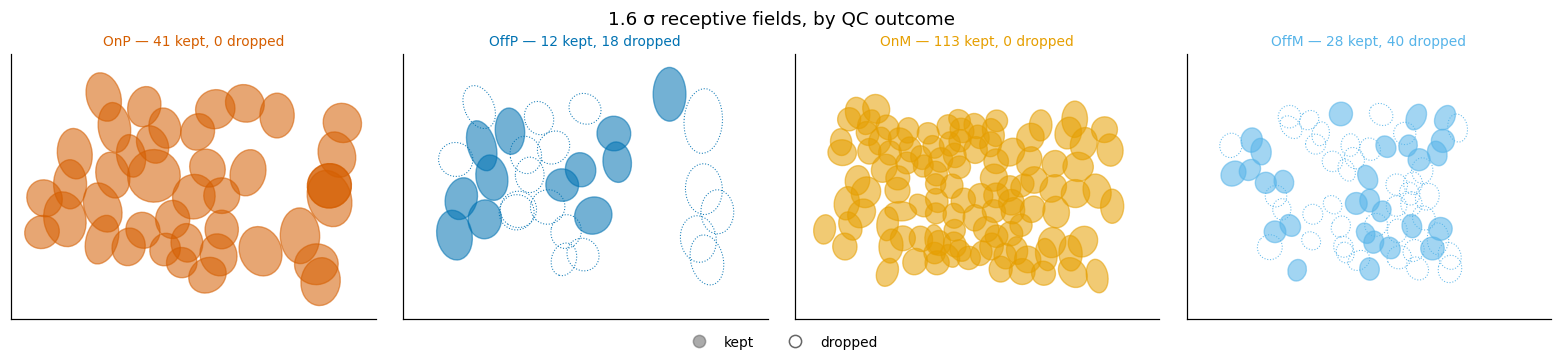

In [11]:
# The same decision in space: 1.6 sigma RF ellipses, filled where the cell was
# kept and open where it was dropped, every panel on one window framed to the
# cells. Even thinning leaves the survivors tiling the array; a hole means the
# population that remains is a region of retina, not a sample of the one you
# started with. zoom=False for the full canvas instead.
EYE_QC_MOSAIC_FIG = ra.plot_qc_mosaic(
    pipeline, qc, cell_types = MAIN_TYPES)
plt.show()


## 5. Where the cycles actually are

Everything after this folds cycle 2 onto cycle 1. So it is worth establishing where they start, and the protocol's own arithmetic gets it wrong.

**Stage renders one frame per display refresh and advances its own clock by `1/declaredRefreshRate` each time.** When the display runs at some other rate the movie plays at the wrong speed. This rig's declared rate is 60 Hz and the recorded frames give **60.31 Hz**, so the movie plays 0.52 % fast:

| | nominal | delivered |
|---|---|---|
| movie onset | 30.000 s | **29.843 s** |
| one cycle | 15.000 s | **14.922 s** |

78 ms is not a rounding error here. It is three to four times a parasol cell's whole response timescale (§6 measures 20 ms), so cycle 2 folded at 15.000 s is misaligned against cycle 1 by more than the width of the features being compared. The correlation between them drops for that reason alone, and the drop looks exactly like the thing this notebook is trying to measure — a representation that changed between presentations.

`ra.repeat_timing` takes both numbers from `frame_times_ms`, the frame monitor's record of when frames actually appeared, and falls back to the nominal arithmetic only when that is missing, saying so. All 24 epochs of this block agree to the millisecond.

**The check is independent.** If cycle 2 is cycle 1 delayed by one cycle, then the lag that maximises the correlation between them *is* the cycle period, measured through the retina rather than through the frame monitor. `ra.estimate_cycle_period` scans it: **14922.1 ms** from the spikes against **14922.0** from the frames, implying a display rate of 60.313 Hz against the frame monitor's 60.314. The two routes share no machinery, so their agreement is a statement that the frame record is being read the way it is being assumed to be read. Run the scan and look at the peak's width before trusting the third decimal place — it is broad, and what it establishes is that the answer is 14.92 and not 15.00, not that it is 14.9221.

movie onset   29527.0 ms   (nominal 30000)
cycle         14764.0 ms   (nominal 15000, -236 ms)
display ran at 59.943 Hz against a declared 59, so the movie plays +1.60 % fast
read from 24 epochs, cycle length spread 0 ms across them
cycle period from spikes   14781.4 ms  (r = 0.726 over 194 cells)
           from frames     14764.0 ms  (+17.4 ms)
           nominal         15000.0 ms  (-218.6 ms)
implied display rate 59.873 Hz against the declared 59


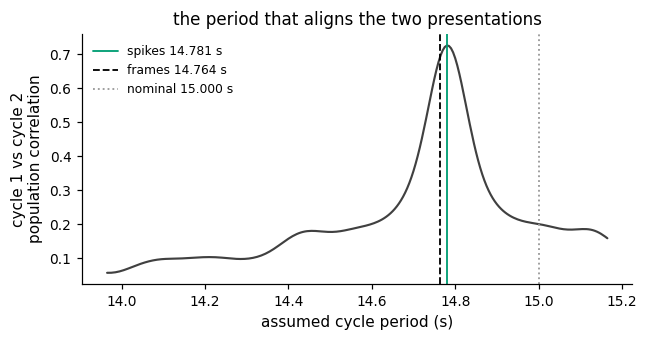

In [12]:
# Where the movie starts and how long a cycle is, from the recorded frames.
TIMING = ra.repeat_timing(stim_block, n_cycles = 2)

# The same number from the spikes. One pass over the population rate, scanned
# over lag — no machinery shared with the frame record above, which is what
# makes the agreement worth anything.
period = ra.estimate_cycle_period(pipeline, stim_block, EPOCH_INDICES, TIMING,
                                  cell_types = MAIN_TYPES, cell_ids = GOOD_CELLS)
EYE_CYCLE_PERIOD_FIG = ra.plot_cycle_period_scan(period)
plt.show()

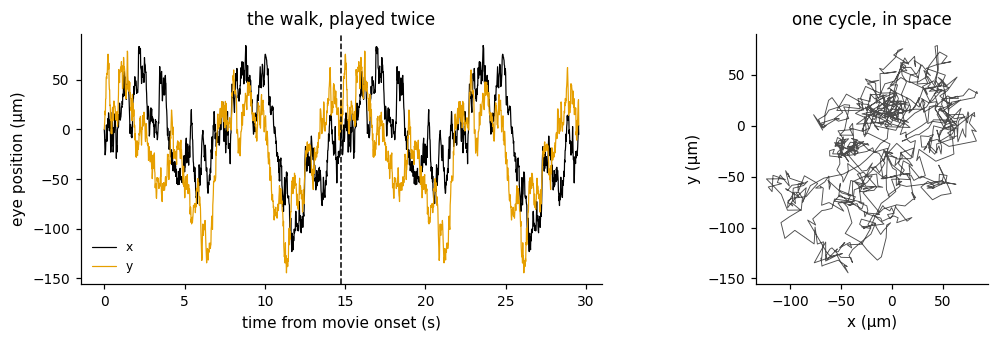

excursion  x -123…84 µm, y -144…79 µm — comparable to one midget receptive field
the loop boundary is not a cut: the jump from the end of cycle 1 to the start of cycle 2 is (5.2, -4.2) µm against a typical step of 5.0 µm


In [13]:
# The stimulus itself, as far as it can be reconstructed. The trajectory is
# recorded per epoch so it is always available; the VH natural images are not
# committed to turner-package, so ra.regen returns trajectories and metadata
# with an empty base_images and there is no frame to render. What the
# trajectory alone establishes is the thing §8 depends on: the second half is
# the first half, sample for sample.
traj = stim_block.df_epochs['epoch_parameters'].iloc[0]
x = np.asarray(traj['xTraj'], dtype = float)
y = np.asarray(traj['yTraj'], dtype = float)
half = len(x) // 2
t_traj = np.arange(len(x)) / TIMING['refresh_actual_hz']

EYE_TRAJECTORY_FIG, axes = plt.subplots(1, 2, figsize = (10.5, 3.2))
axes[0].plot(t_traj, x, lw = .8, label = 'x')
axes[0].plot(t_traj, y, lw = .8, label = 'y')
axes[0].axvline(TIMING['cycle_ms'] / 1000, color = 'k', lw = 1, ls = '--')
axes[0].set_xlabel('time from movie onset (s)')
axes[0].set_ylabel('eye position (µm)')
axes[0].set_title('the walk, played twice')
axes[0].legend(frameon = False, fontsize = 8)
axes[1].plot(x[:half], y[:half], lw = .6, color = '0.3')
axes[1].set_xlabel('x (µm)'); axes[1].set_ylabel('y (µm)')
axes[1].set_aspect('equal')
axes[1].set_title('one cycle, in space')
plt.tight_layout(); plt.show()

step = np.median(np.abs(np.diff(x[:half])))
print(f'excursion  x {x.min():.0f}…{x.max():.0f} µm, y {y.min():.0f}…{y.max():.0f} µm '
      f'— comparable to one midget receptive field')
print(f'the loop boundary is not a cut: the jump from the end of cycle 1 to the '
      f'start of cycle 2 is ({x[half] - x[half-1]:.1f}, {y[half] - y[half-1]:.1f}) µm '
      f'against a typical step of {step:.1f} µm')


## 6. How fine a timescale does each pathway reproduce?

Every later choice of temporal resolution — the PSTH kernel in §7, the Victor-Purpura cost in §10 — has to come from somewhere. Choosing it to maximise the effect under test is how a pathway difference in timescale becomes whatever the analyst expected, and using one value for every type is worse than either: it blurs parasol responses to match midget cells, or scores midget cells at a resolution their responses do not have.

So it is measured, and the measurement is a **bandwidth**: the highest frequency at which repeats of the same movie agree. Trials of one condition are repeats, so at each frequency the cross-spectrum between two of them estimates the signal power while the auto-spectrum estimates signal plus independent spiking noise, and their ratio is the reproducible fraction of power at that frequency. The cutoff is where it meets a noise floor taken from the cell's own spectrum above 100 Hz, where nothing is reproducible by construction — so the floor accounts for having only three repeats without assuming what it should be.

**A time-domain autocorrelation width does not work here**, and was the first thing tried. These responses carry a large and highly reproducible slow envelope — the movie's own luminance wanders, and the retina is adapting — which puts most of the autocorrelation's area at long lags: two thirds of the cells never reached `1/e` inside 400 ms and the rest returned the bin width. Slow structure lives at low frequency and simply does not affect a cutoff.

**What comes out**, on this block, cleanly ordered and without being asked to be:

| | cutoff | σ |
|---|---|---|
| OnP | 9.5 Hz | 20 ms |
| OffP | 8.9 Hz | 21 ms |
| OnM | 6.7 Hz | 28 ms |
| OffM | 5.7 Hz | 33 ms |

Parasol cells reproduce structure to about 9 Hz and midget cells to about 6, so the kernels come out 20 ms and 30 ms — the ranges these pathways are usually quoted at, arrived at from this retina's spikes. σ is the Gaussian whose **half-power point sits at the cutoff**: a kernel narrower than that spends its resolution on frequencies where the cell agrees with itself no better than chance.

**The per-type number is read off the per-type mean spectrum, not averaged over per-cell ones.** A single cell's coherence over three repeats has a noise floor an order of magnitude above the floor of a mean over ninety cells, so per-cell cutoffs are systematically early — their median half-period is 126–206 ms against the 53–88 ms the type curves give. The per-cell column is in `.per_cell` because its spread is worth seeing; it is not what the kernel comes from, and the right panel of the figure is labelled to say so.

193 of 194 cells reproduce anything (peak coherence above 0.02 and above their own 100–240 Hz noise floor), over 12 repeat sets of 4 trials

           n_cells  peak_coherence  noise_floor  f_cutoff_hz  tau_ms  sigma_ms  vp_cost_per_s  cell_median_tau_ms
cell_type                                                                                                        
OffM            28             0.6          0.0         12.7    39.5        15           50.6                57.8
OffP            12             0.7          0.0         25.9    19.3         7          103.6                27.9
OnM            113             0.6          0.0         21.5    23.3         9           85.8                48.8
OnP             41             0.4          0.0         26.7    18.7         7          106.8                40.0


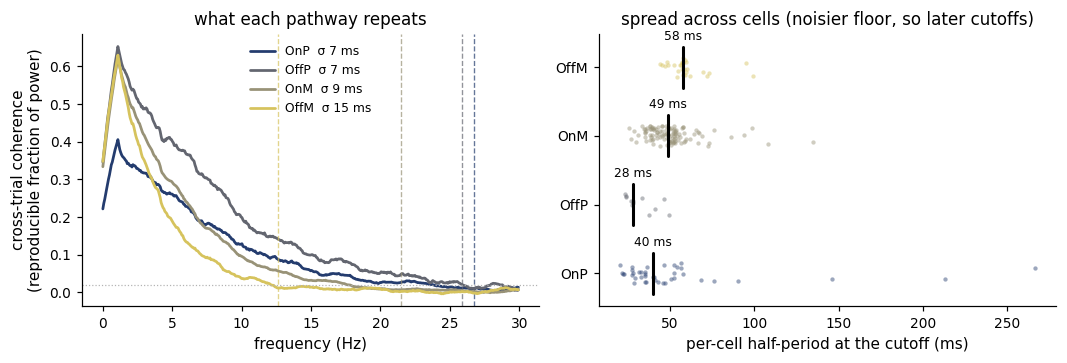


smoothing  {'OnP': 7.0, 'OffP': 7.0, 'OnM': 9.0, 'OffM': 15.0}
VP cost    {'OnP': 106.8, 'OffP': 103.6, 'OnM': 85.8, 'OffM': 50.6} per second


In [14]:
# Repeat sets are (condition x cycle) groups of epochs — three trials each,
# sixteen sets. Pooling across conditions instead would compare responses to
# different stimuli and read the difference as noise.
TIMESCALE = ra.response_timescale(pipeline, stim_block, epochs_kept, TIMING,
                                  condition_keys = CONDITION_KEYS,
                                  cell_types = MAIN_TYPES,
                                  cell_ids   = GOOD_CELLS)

EYE_TIMESCALE_FIG = ra.plot_response_timescale(
    TIMESCALE, cell_types = MAIN_TYPES)
plt.show()

# These two dicts are the only place the timescale enters the analysis.
SIGMA_MS = TIMESCALE.sigma_ms(MAIN_TYPES)
VP_COST  = TIMESCALE.vp_cost_per_s(MAIN_TYPES)
print(f'\nsmoothing  {SIGMA_MS}')
print(f'VP cost    { {k: round(v, 1) for k, v in VP_COST.items()} } per second')


## 7. The population response, as a matrix

`ra.repeat_response` puts every cycle of every epoch on the **same** movie-time axis, so a column of the array is one moment of the movie regardless of which presentation or which epoch it came from. That is what makes everything below a comparison of representations rather than of timing — provided §5's numbers are right, which is what §5 was for. The result is one `(cell, epoch, cycle, movie time)` array that every later section reads, so the cell set, the smoothing and the cycle alignment are decided once and cannot drift apart between sections.

Smoothing is per cell type, from §6. Binning is 5 ms and the Gaussian runs in `mode='nearest'`, not `'wrap'` — the loop repeats the trajectory rather than being periodic, and although the boundary turns out to be seamless (§5: a 3 µm jump against a 3 µm typical step) wrapping would still smear the last frames of cycle 1 into the first frames of cycle 2, which are the frames the whole recovery question is about.

**Reading the figure.** Cells are blocked by type and ordered within type by receptive-field position. Every panel shares one colour scale, because the two histories differ in mean rate by a factor of two in the first presentation and that difference is half of what is being shown — but a shared scale leaves the low-rate types dark, so `scale_by='type'` gives each block its own and is the one to look at for temporal structure.

What is visible before anything is computed, in the first two or three seconds of presentation 1: after the **dim** background the ON blocks are bright and unstructured — the movie is an increment and they burst at it — while after the **bright** background the same OnM block is nearly *empty* and it is OffM that carries a band at movie onset, because for those cells the movie is a decrement. The two histories are not a strong and a weak version of one response; at movie onset they are close to opposite ones. By the middle of presentation 1 both panels have settled into the same vertical structure, and in presentation 2 they look like each other throughout. §11 puts numbers on how fast that happens.

In [15]:
REPEAT = ra.repeat_response(pipeline, stim_block, epochs_kept, TIMING,
                            condition_keys = CONDITION_KEYS,
                            cell_types = MAIN_TYPES,
                            cell_ids   = GOOD_CELLS,
                            sigma_ms   = SIGMA_MS,
                            bin_ms     = 5.0)

RepeatResponse(194 cells x 24 epochs x 2 cycles x 2952 bins of 5 ms, 110 MB)
movie time 0–14.76 s per cycle, 2 cycles, aligned on 29.527 s + k x 14.764 s
smoothing: OffM 15 ms, OffP 7 ms, OnM 9 ms, OnP 7 ms


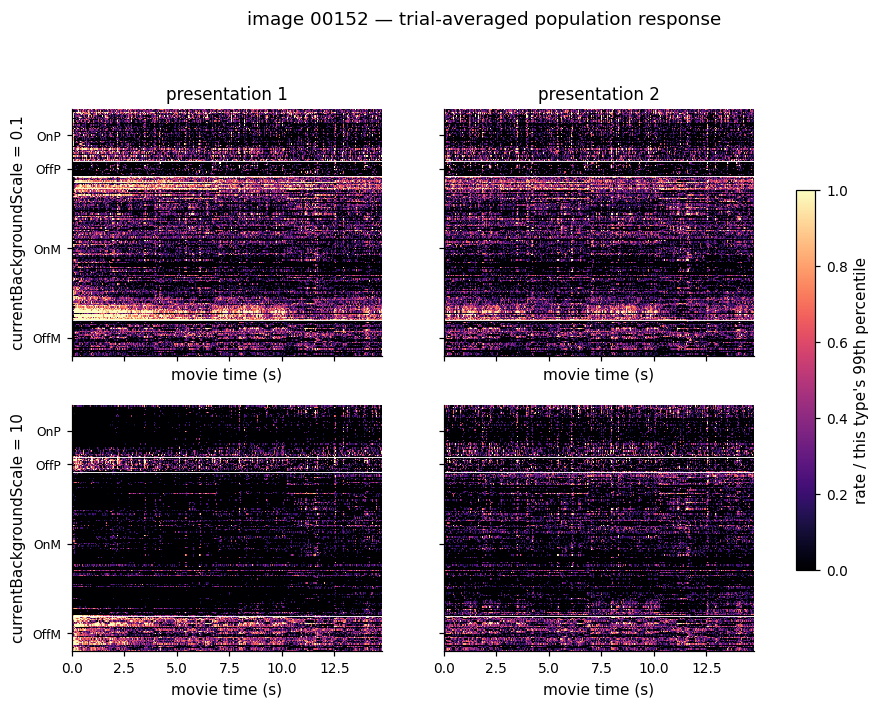

In [16]:
# <-- EDIT ME: which image to draw. One image, because a different image is a
# different movie and the two matrices would not be comparable.
SHOW_IMAGE = '00152'
SCALE_BY   = 'type'   # 'all' to put every panel on one rate scale

EYE_POPULATION_MATRICES_FIG = ra.plot_population_matrices(
    REPEAT, contrast_key = 'currentBackgroundScale',
    group = {'currentImageName': SHOW_IMAGE},
    cell_types = MAIN_TYPES, scale_by = SCALE_BY)
EYE_POPULATION_MATRICES_FIG.suptitle(
    f'image {SHOW_IMAGE} — trial-averaged population response', y = 1.02)
plt.show()


## 8. The measurement: do the two histories converge?

For each image and each presentation, average the three repeats of each history into a `(cell x time)` matrix, vectorise, and correlate the two. That is the population quantity — it asks whether the *joint* pattern across cells and time matches, not whether each cell's trace does — and it is computed alongside the mean single-cell correlation so the two questions stay separate.

**Three things it has to be divided by, or it measures the wrong thing.**

- **Repeat reliability.** A population that cannot reproduce itself cannot resemble anything else, and without correcting for that a noisier population reads as a more adapted one. `rho_corrected = rho_cross / sqrt(rho_within_dim x rho_within_bright)`, where each `rho_within` is the reliability of *that condition's three-trial mean*: every distinct pair of single trials is correlated and Spearman-Brown carries the result from one trial up to three. With three repeats that enumerates every pair, which is the finest-grained version of "average over all splits" and the only one that does not have to choose between unequal halves. (`reliability_method='split_half'` gives the more familiar form; with an odd number of trials its halves are 1 and 2 and it comes out lower.)
- **What the correlation is *of*.** `raw` correlates rates and is inflated by cells simply differing from each other in mean rate — a difference identical between conditions by construction. `centered` removes each cell's own mean, so gain differences survive but that offset does not. `shape` z-scores each cell, so gain and baseline are gone and only the temporal pattern is left. All three are reported: raw versus shape is what separates "adaptation changed the gain" from "adaptation changed the response".
- **Population size.** A vector correlation over 94 midget cells and one over 26 parasol cells are not the same estimator. `match_cells='min'` draws every type down to the smallest type's count, ten times without replacement, and averages — so a pathway claim does not turn on which type the array happened to sample more of.

### What this block shows

**The representations converge, and most of it happens inside the first presentation.** Noise-corrected, centered, pooled over the four images:

| | presentation 1 | presentation 2 |
|---|---|---|
| whole population (250 cells) | **0.32** | **0.90** |
| OnP (matched to 26) | 0.10 | 0.94 |
| OffP | 0.18 | 0.84 |
| OnM | 0.40 | 0.93 |
| OffM | 0.43 | 0.85 |

Two things to read off it. First, **every type converges**, and by presentation 2 the dim- and bright-history responses are as similar as three repeats of the same condition are — 0.84 to 0.94 against a ceiling of 1. Second, **the pathways start from different places**: parasol populations are near-orthogonal in the first presentation (OnP 0.10) while midget populations already retain a good deal of common structure (0.40–0.43). So Δρ is *larger* for parasol cells, which is the opposite of the reading where midget cells are the slow ones — what recovers slowly is the pathway that was disrupted most, not the one with the slowest kinetics. §12 checks that this is not simply a consequence of parasol cells being faster.

Matching to 26 cells changes essentially nothing (OnM 0.404 → 0.396 unmatched to matched), so the pathway difference is not a population-size artefact.

**Gain versus pattern.** Raw and shape tell different halves of it. Mean rate goes 15.6 → 12.3 Hz for dim history and 7.0 → 9.2 Hz for bright — a 2.2x gain difference in presentation 1 falling to 1.3x in presentation 2. Corrected correlations run 0.32 → 0.90 centered, 0.32 → 0.83 raw and 0.28 → 0.71 shape. So **both** the gain and the temporal pattern differ in presentation 1 and **both** converge; the shape component converges less completely, which is the part that a gain-only account of adaptation does not predict.

**Mean single-cell correlation is much lower than population correlation** — 0.19 → 0.38 against 0.32 → 0.90 — and both roughly double. They are not measuring the same thing: single cells are noisy and their individual traces stay only moderately alike, while the pattern *across* the mosaic is what recovers. Both moving together in every type is what makes the pathway result worth stating.

**One image behaves differently.** `00459` gives 0.11 in presentation 1 against 0.35–0.45 for the other three, and only reaches 0.79 in presentation 2. It is the brightest image (mean 0.358), so its dim background is the largest absolute step, and it is also the one where the 10x request clipped hardest (§2: 2.8x delivered). It also fires least — 11.9 and 4.4 Hz against 16–18 and 7.5–8.2 — so its repeats are the least reliable and its correction the largest. Which of those explains it, one retina cannot say; that it is one image out of four is why the figure draws images as individual lines under the mean.

In [17]:
# The headline. Grouped by image, contrasted on background scale, matched to
# the smallest type's cell count.
SIM = ra.population_similarity(REPEAT,
                               contrast_key = 'currentBackgroundScale',
                               cell_types   = MAIN_TYPES,
                               match_cells  = 'min',
                               n_resamples  = 10)
print(f"matched to n = {SIM.attrs['matched_n_cells']} cells per type\n")

print('per image, whole population, centered:')
display(SIM.query("cell_type == 'all' and normalize == 'centered'")
           .set_index([CONDITION_KEYS[0], 'cycle'])[
               ['rho_cross', 'rho_within_a', 'rho_within_b', 'rho_corrected',
                'rho_cell', 'rate_a_hz', 'rate_b_hz']].round(3))

print('\nper cell type, mean over images, centered:')
display(SIM.query("normalize == 'centered'")
           .groupby(['cell_type', 'cycle'])[
               ['n_cells', 'n_available', 'rho_cross', 'rho_within_a',
                'rho_within_b', 'rho_corrected', 'rho_cell']]
           .mean().round(3))

matched to n = 12 cells per type

per image, whole population, centered:


rho_cross  rho_within_a  rho_within_b  rho_corrected  \
currentImageName cycle                                                         
00152            1          0.227         0.562         0.568          0.401   
                 2          0.437         0.488         0.479          0.903   
01769            1          0.199         0.577         0.571          0.347   
                 2          0.434         0.485         0.462          0.917   
03760            1          0.233         0.593         0.592          0.394   
                 2          0.469         0.518         0.499          0.924   

                        rho_cell  rate_a_hz  rate_b_hz  
currentImageName cycle                                  
00152            1         0.248     10.586      3.988  
                 2         0.422      8.491      5.386  
01769            1         0.176     10.263      3.677  
                 2         0.333      7.725      5.066  
03760            1         0.264     10.744      3.832  
                 2         0.429      8.191      5.483


per cell type, mean over images, centered:


n_cells  n_available  rho_cross  rho_within_a  rho_within_b  \
cell_type cycle                                                                
OffM      1         12.0         28.0      0.441         0.580         0.738   
          2         12.0         28.0      0.563         0.588         0.626   
OffP      1         12.0         12.0      0.331         0.596         0.682   
          2         12.0         12.0      0.534         0.582         0.518   
OnM       1         12.0        113.0      0.233         0.623         0.534   
          2         12.0        113.0      0.473         0.535         0.521   
OnP       1         12.0         41.0      0.152         0.481         0.342   
          2         12.0         41.0      0.322         0.345         0.315   
all       1        194.0        194.0      0.220         0.577         0.577   
          2        194.0        194.0      0.447         0.497         0.480   

                 rho_corrected  rho_cell  
cell_type cycle                           
OffM      1              0.672     0.408  
          2              0.929     0.487  
OffP      1              0.519     0.266  
          2              0.974     0.423  
OnM       1              0.393     0.207  
          2              0.893     0.405  
OnP       1              0.374     0.135  
          2              0.979     0.283  
all       1              0.381     0.230  
          2              0.915     0.395

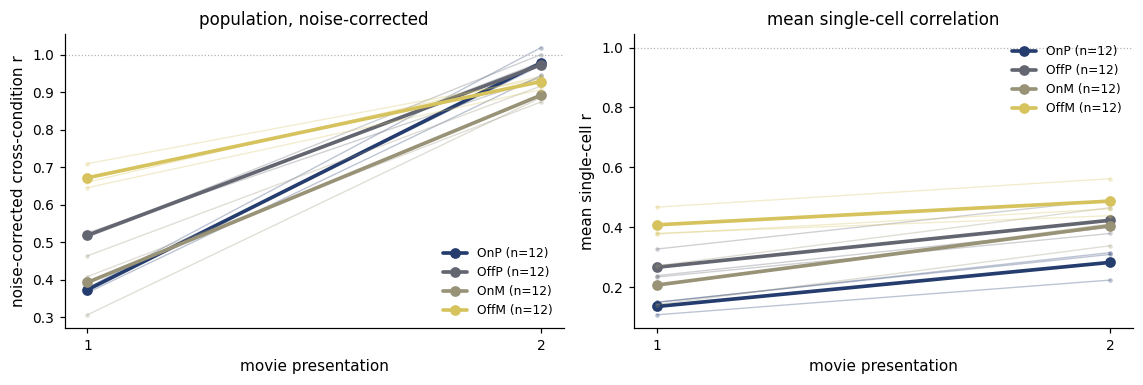

whole population, by what the correlation is of:


rho_cross  rho_within_a  rho_within_b  rho_corrected  \
normalize cycle                                                         
centered  1          0.220         0.577         0.577          0.381   
          2          0.447         0.497         0.480          0.915   
raw       1          0.122         0.763         0.700          0.167   
          2          0.527         0.665         0.591          0.840   
shape     1          0.227         0.557         0.547          0.409   
          2          0.392         0.493         0.490          0.796   

                 rate_a_hz  rate_b_hz  
normalize cycle                        
centered  1         10.531      3.832  
          2          8.136      5.312  
raw       1         10.531      3.832  
          2          8.136      5.312  
shape     1         10.531      3.832  
          2          8.136      5.312

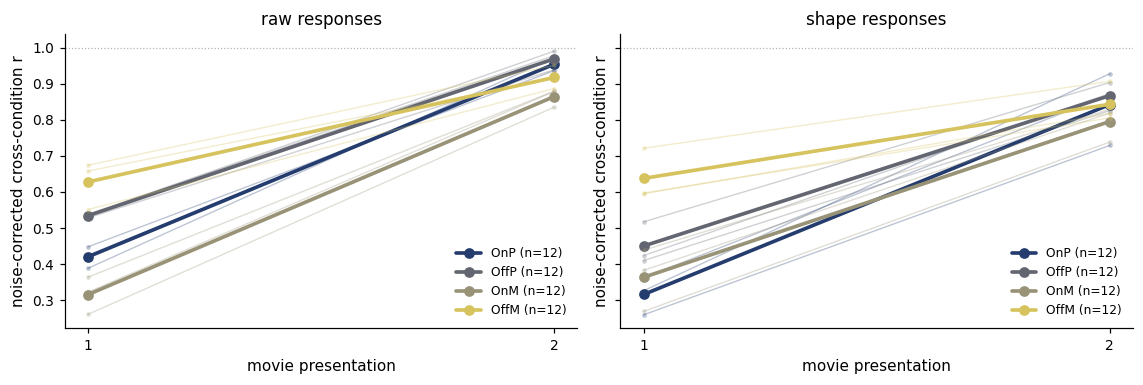

In [18]:
# Panel C/D: the population measure and the single-cell measure side by side,
# with each image drawn as its own faint line under the mean. An effect
# carried by one image is visible here and nowhere in a table of means.
EYE_SIMILARITY_POP_VS_CELL_FIG, axes = plt.subplots(
    1, 2, figsize = (10.5, 3.6))
ra.plot_population_similarity(SIM, cell_types = MAIN_TYPES,
                              value = 'rho_corrected', ax = axes[0],
                              title = 'population, noise-corrected')
ra.plot_population_similarity(SIM, cell_types = MAIN_TYPES,
                              value = 'rho_cell', ax = axes[1],
                              title = 'mean single-cell correlation')
plt.tight_layout(); plt.show()

# Panel F: gain versus temporal pattern. `raw` keeps everything, `shape`
# z-scores each cell so only the pattern is left. Both converge; shape less.
print('whole population, by what the correlation is of:')
display(SIM.query("cell_type == 'all'")
           .groupby(['normalize', 'cycle'])[
               ['rho_cross', 'rho_within_a', 'rho_within_b', 'rho_corrected',
                'rate_a_hz', 'rate_b_hz']].mean().round(3))

EYE_SIMILARITY_NORMALIZATION_FIG, axes = plt.subplots(
    1, 2, figsize = (10.5, 3.6), sharey = True)
for ax, how in zip(axes, ['raw', 'shape']):
    ra.plot_population_similarity(SIM, cell_types = MAIN_TYPES,
                                  normalize = how, ax = ax,
                                  title = f'{how} responses')
plt.tight_layout(); plt.show()


## 9. First versus second presentation, and whether the change depends on history

§8 compared the two histories to each other. The same array supports the other comparison — each history to itself, across presentations — and that one needs care, because a response can change between two presentations of a movie for reasons that have nothing to do with adaptation history.

- `rho_cycle` is cycle 1 against cycle 2 *within* one condition, and `rho_cycle_corrected` divides it by that condition's own repeat reliability in each cycle, for the same reason §8 does: a condition whose repeats are noisier has a lower cycle-to-cycle correlation for that reason alone.
- **The interaction is the stronger test.** `dR = R_cycle2 − R_cycle1` is what each history changed between presentations. If that change were a generic repetition effect — habituation, a slow rundown, anything that does not know which background preceded it — the two histories' `dR` would be the same vector. `rho_delta` is their correlation and `delta_ratio` is the norm of their difference over the mean of their norms: **0 if the two changes are identical, √2 ≈ 1.41 if they are orthogonal, 2 if opposite.**

**On this block the two changes are orthogonal.** `rho_delta` runs 0.02–0.08 (OnP −0.06) and `delta_ratio` 1.39–1.49 across every type, against √2 = 1.414 for exactly orthogonal. So what happens between the two presentations is specific to the preceding luminance and is not a repetition effect the two conditions share — which is the result that licenses reading §8's convergence as recovery.

`rho_cycle_corrected` itself is 0.48–0.73 and does not separate the two histories cleanly (OnP is the one exception, 0.48 after the dim background against 0.68 after the bright). With four images and one retina that difference is a direction to check on more preparations, not a finding.

In [19]:
CYCLE = ra.cycle_interaction(REPEAT, contrast_key = 'currentBackgroundScale',
                             cell_types = MAIN_TYPES,
                             normalizations = ('centered', 'shape'))

print('centered. rho_delta near 0 and delta_ratio near sqrt(2) = 1.414 mean the '
      'two histories changed in unrelated directions:\n')
display(CYCLE.query("normalize == 'centered'")
             .groupby(['cell_type', 'currentBackgroundScale'])[
                 ['rho_cycle', 'rho_cycle_corrected', 'delta_rel',
                  'rho_delta', 'delta_ratio']].mean().round(3))

centered. rho_delta near 0 and delta_ratio near sqrt(2) = 1.414 mean the two histories changed in unrelated directions:



rho_cycle  rho_cycle_corrected  delta_rel  \
cell_type currentBackgroundScale                                              
OffM      0.1                         0.525                0.889      0.956   
          10.0                        0.528                0.778      0.883   
OffP      0.1                         0.465                0.788      1.032   
          10.0                        0.303                0.509      0.992   
OnM       0.1                         0.441                0.745      0.996   
          10.0                        0.398                0.717      1.384   
OnP       0.1                         0.205                0.518      1.165   
          10.0                        0.199                0.658      1.522   
all       0.1                         0.376                0.701      1.050   
          10.0                        0.337                0.640      1.237   

                                  rho_delta  delta_ratio  
cell_type currentBackgroundScale                          
OffM      0.1                         0.050        1.399  
          10.0                        0.050        1.399  
OffP      0.1                         0.116        1.426  
          10.0                        0.116        1.426  
OnM       0.1                         0.085        1.384  
          10.0                        0.085        1.384  
OnP       0.1                         0.070        1.391  
          10.0                        0.070        1.391  
all       0.1                         0.075        1.374  
          10.0                        0.075        1.374


## 10. The same question in spike-train distance

The single-cell metric this notebook used to be built on, kept as it was, with the one correction that makes it comparable across conditions: subtract the distance the *same* condition's repeats already show.

`d_excess = d_cross − (d_within_dim + d_within_bright) / 2`

Costs are per cell type, from §6 — `q = 2/τ`, because Victor-Purpura shifts a spike at cost `q·dt` and deleting plus inserting costs 2, so `2/q` is the metric's own resolution and this sets it to the measured timescale. Scoring a parasol cell on a midget's clock is the mistake this avoids.

### Read this section's numbers against the control, not on their own

`d_excess` declines from presentation 1 to presentation 2 in every type — OnM 0.26 → 0.05, OnP 0.16 → 0.02, OffM 0.17 → 0.10, OffP 0.10 → 0.04 — which looks like §8 in a different metric. It is not, quite.

**Victor-Purpura distance grows with spike count, and at cost 0 it *is* the count difference `|n_a − n_b|`.** The two histories fire at genuinely different rates (15.6 vs 7.0 Hz in presentation 1, 12.3 vs 9.2 in presentation 2), so a pure rate convergence moves `d_excess` in the same direction, on the same timescale, as a timing convergence would. `d_excess_count_only` is the whole statistic recomputed with that count-only metric: 0.40 → 0.10 for OnM, 0.29 → 0.04 for OnP, 0.40 → 0.32 for OffM, 0.29 → 0.24 for OffP. `d_excess` is roughly half of it and falls by about the same factor, so **the decline here is rate convergence seen through a timing metric** and is not independent evidence about timing.

That is not a defect of the measurement, it is what the measurement is: spike distance mixes rate and timing on purpose. The place to look for a timing-specific answer is §8's `shape` normalisation, which removes each cell's gain by construction and still shows convergence (0.28 → 0.71). Reporting both is the point — the dotted lines in the figure are the count-only version, drawn on the same axes so the comparison cannot be skipped.

46560 Victor-Purpura pairs over 9312 trains, 4 cost value(s): 50.6/s, 85.8/s, 103.6/s, 106.8/s


d_cross  d_within_a  d_within_b  d_excess  \
cell_type cycle                                              
OffM      1       0.7295      0.7014      0.5366    0.1128   
          2       0.7164      0.7188      0.6447    0.0339   
OffP      1       0.8781      0.8214      0.6849    0.1249   
          2       0.8311      0.8238      0.8112    0.0136   
OnM       1       0.8974      0.6482      0.8228    0.1609   
          2       0.7772      0.6980      0.7755    0.0383   
OnP       1       0.9149      0.7526      0.8810    0.0977   
          2       0.8330      0.8046      0.8441    0.0086   

                 d_excess_count_only  
cell_type cycle                       
OffM      1                   0.3436  
          2                   0.1898  
OffP      1                   0.5348  
          2                   0.1886  
OnM       1                   0.4828  
          2                   0.2008  
OnP       1                   0.4943  
          2                   0.1278

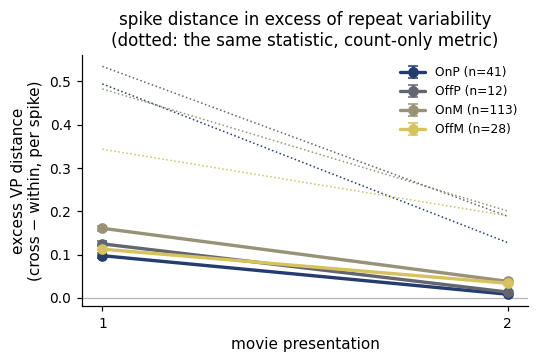

In [20]:
# One flat list of trains and one C call per cost value. ~40k pairs, a second.
DIST = ra.population_spike_distance(pipeline, REPEAT,
                                    contrast_key = 'currentBackgroundScale',
                                    cost_per_s   = VP_COST,
                                    cell_types   = MAIN_TYPES)

display(DIST.groupby(['cell_type', 'cycle'])[
    ['d_cross', 'd_within_a', 'd_within_b', 'd_excess', 'd_excess_count_only']]
    .mean().round(4))

EYE_SPIKE_DISTANCE_FIG = ra.plot_excess_distance(
    DIST, cell_types = MAIN_TYPES)
plt.show()


## 11. The trajectory

Presentation 1 versus presentation 2 says recovery happened; it does not say when. Cutting each cycle into sections and repeating the measurement inside each gives a coarse time course, and the repeat makes it interpretable: **section *k* of cycle 1 and section *k* of cycle 2 contain identical stimulus content**, so the difference between them is time since the step and nothing else. Without that, a similarity that changes across a 15 s movie could as easily be the movie.

`n_sections` divides the cycle evenly rather than taking a fixed width, and that is the point: the cycle is 14.922 s, so asking for 5 s sections would leave 4.9 s — a third of the movie — unanalysed. Three sections of 4.97 s is the version that covers it. Sections much shorter than 3 s are not worth asking for: with three repeats the reliability estimate being divided by is too noisy.

**Convergence is fast and it is mostly done inside the first presentation.** Whole population, noise-corrected, centered:

| time since movie onset | 2.5 s | 7.5 s | 12.4 s | 17.4 s | 22.4 s | 27.4 s |
|---|---|---|---|---|---|---|
| all | 0.13 | 0.67 | 0.85 | 0.91 | 0.91 | 0.93 |
| OnP | −0.00 | 0.60 | 0.89 | 1.01 | 0.91 | 0.92 |
| OffP | −0.02 | 0.45 | 0.75 | 0.85 | 0.89 | 0.74 |
| OnM | 0.24 | 0.71 | 0.88 | 0.93 | 0.95 | 0.96 |
| OffM | 0.18 | 0.72 | 0.83 | 0.85 | 0.91 | 0.88 |

In the first five seconds the two parasol populations carry **no** shared representation of the movie at all — 0.00 and −0.02, which is what an uncorrelated pair looks like — while the midget populations already retain 0.18–0.24. By 12.4 s, still inside presentation 1, every type is at 0.75–0.89, and the second presentation adds little. So the recovery timescale is a few seconds, not the fifteen the presentation structure suggests, and the cycle boundary is not where the interesting part happens.

The values at and above 1.0 (OnP at 17.4 s) are the correction dividing by a reliability estimated from three trials; read them as "at the ceiling", not as more similar than repeats of the same condition.

cell_type,OffM,OffP,OnM,OnP,all
t_since_movie_s,,,,,
2.46,0.550,0.359,0.254,0.180,0.190
7.38,0.846,0.847,0.635,0.784,0.643
12.30,0.901,0.906,0.813,0.904,0.816
17.22,0.907,0.964,0.877,0.934,0.883
22.14,0.937,0.968,0.937,0.993,0.939
27.06,0.961,1.006,0.967,1.024,0.972


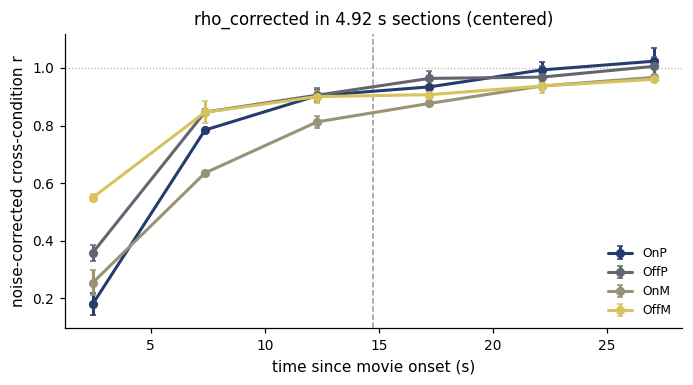

In [21]:
TRAJ = ra.time_resolved_similarity(REPEAT,
                                   contrast_key = 'currentBackgroundScale',
                                   cell_types = MAIN_TYPES,
                                   n_sections = 3)

display(TRAJ.query("normalize == 'centered'")
            .groupby(['cell_type', 't_since_movie_s'])['rho_corrected']
            .mean().unstack(0).round(3))

EYE_TIME_RESOLVED_FIG = ra.plot_time_resolved_similarity(
    TRAJ, cell_types = MAIN_TYPES)
plt.show()


## 12. The common-timescale control

§6 gave each pathway its own kernel, which is the right way to ask how different the two adaptation states are *when each pathway is evaluated at the resolution it actually represents the movie at*. It also means the parasol and midget numbers were computed differently, so a pathway difference could in principle be a kernel difference.

The control is to redo §8 with one kernel for everything. **It changes nothing that matters**: at a common 50 ms the whole population goes 0.32 → 0.91 against 0.32 → 0.90 at native resolution, and every type lands within 0.05 of where it was — OnP 0.08 → 0.95, OffP 0.20 → 0.79, OnM 0.39 → 0.94, OffM 0.44 → 0.85. The largest single shift is OffP's second presentation, 0.84 native to 0.79 common, on 26 cells. The ordering that matters — parasol populations starting near zero and midget populations at 0.4 — is untouched, so the pathway-specific recovery is not explained by parasol cells having faster responses.

That is a reassuring result and also a slightly deflating one about the method: at these repeat counts the population correlation is dominated by structure well below 10 Hz, so the temporal resolution has little room to matter. The place the native timescale earns its keep is §10, where the Victor-Purpura cost sets what counts as a coincidence.

In [22]:
# One kernel for every type. Everything else identical to §8.
COMMON_SIGMA_MS = 50.0

REPEAT_COMMON = ra.repeat_response(pipeline, stim_block, epochs_kept, TIMING,
                                   condition_keys = CONDITION_KEYS,
                                   cell_types = MAIN_TYPES,
                                   cell_ids   = GOOD_CELLS,
                                   sigma_ms   = COMMON_SIGMA_MS,
                                   bin_ms     = 5.0,
                                   verbose    = False)

SIM_COMMON = ra.population_similarity(REPEAT_COMMON,
                                      contrast_key = 'currentBackgroundScale',
                                      cell_types   = MAIN_TYPES,
                                      match_cells  = 'min',
                                      n_resamples  = 10,
                                      normalizations = ('centered',))

native = (SIM.query("normalize == 'centered'")
             .groupby(['cell_type', 'cycle'])['rho_corrected'].mean())
common = SIM_COMMON.groupby(['cell_type', 'cycle'])['rho_corrected'].mean()
display(pd.DataFrame({f'native ({SIGMA_MS})': native,
                      f'common ({COMMON_SIGMA_MS:g} ms)': common,
                      'difference': common - native}).round(3))

native ({'OnP': 7.0, 'OffP': 7.0, 'OnM': 9.0, 'OffM': 15.0})  \
cell_type cycle                                                                 
OffM      1                                                  0.672              
          2                                                  0.929              
OffP      1                                                  0.519              
          2                                                  0.974              
OnM       1                                                  0.393              
          2                                                  0.893              
OnP       1                                                  0.374              
          2                                                  0.979              
all       1                                                  0.381              
          2                                                  0.915              

                 common (50 ms)  difference  
cell_type cycle                              
OffM      1               0.668      -0.004  
          2               0.946       0.017  
OffP      1               0.494      -0.025  
          2               0.975       0.001  
OnM       1               0.326      -0.068  
          2               0.892      -0.001  
OnP       1               0.221      -0.152  
          2               0.931      -0.048  
all       1               0.335      -0.045  
          2               0.906      -0.009

## 13. Midget versus parasol recovery timescale

The primary comparison is **OnM versus OnP**. `TRAJ` measures how quickly the two adaptation histories converge in population-response space; images are averaged within this retina before fitting. For cross-date plotting, each retina and cell type is scaled so its earliest point is 0 and the mean of its final two sections is 1. This affine normalization preserves the fitted exponential timescale while preventing dates with larger response amplitudes from dominating.

The fit is descriptive for one retina. The inferential unit is the retina, so the saved `tau` and `t50` values are compared as paired OnM–OnP observations across dates. All available `MAIN_TYPES` remain in the saved recovery, response-timescale, and supporting analysis tables.

,exp_name,cell_type,metric,n_cells,n_observations,tau_s,tau_ci_low,tau_ci_high,tau_bounded,t50_s,t50_ci_low,t50_ci_high,r_squared,n_points,fit_error
0,20250924C,OffM,recovery_fraction,28,18,3.668,2.833,246.000,False,5.006,4.428,172.983,0.989,6,
1,20250924C,OffP,recovery_fraction,12,18,3.433,2.425,244.944,False,4.846,4.150,172.248,0.991,6,
2,20250924C,OnM,recovery_fraction,113,18,6.741,5.897,20.872,True,7.134,6.559,16.938,0.999,6,
3,20250924C,OnP,recovery_fraction,41,18,3.854,3.114,246.000,False,5.142,4.625,172.983,0.993,6,


,exp_name,cell_type_a,cell_type_b,tau_s_OnM,tau_s_OnP,tau_s_diff_OnM_minus_OnP,tau_s_ratio_OnM_over_OnP,t50_s_OnM,t50_s_OnP,t50_s_diff_OnM_minus_OnP,t50_s_ratio_OnM_over_OnP,n_cells_OnM,n_cells_OnP
0,20250924C,OnM,OnP,6.741,3.854,2.886,1.749,7.134,5.142,1.993,1.388,113,41


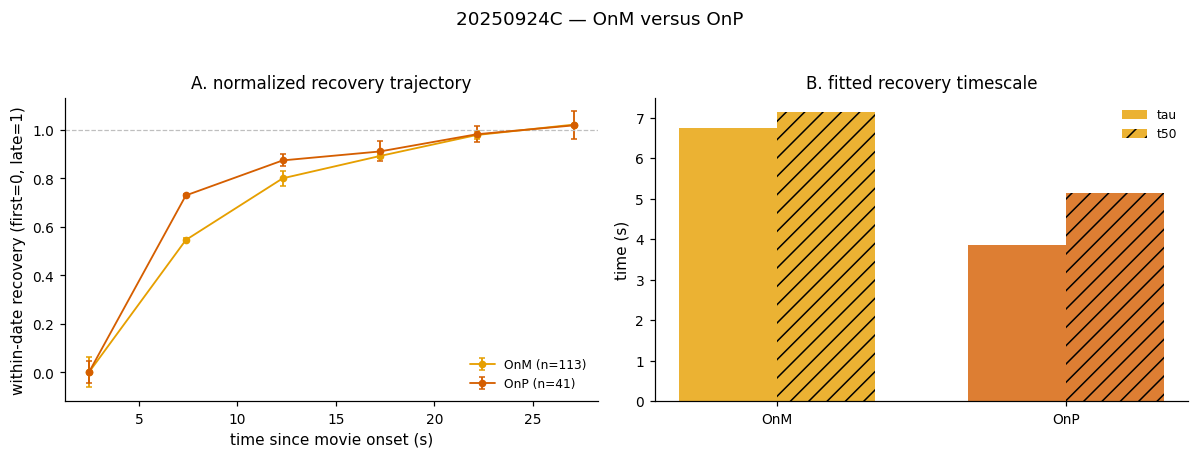

In [23]:
EYE_COMPARE_TYPES = ('OnM', 'OnP')
EYE_CELL_TYPES_TO_SAVE = tuple(MAIN_TYPES)
EYE_RECOVERY_LATE_POINTS = 2
EYE_RECOVERY_SKIP_FIRST_S = 0.0

EYE_CELL_TYPE_RECOVERY = ra.summarize_eye_movement_cell_type_recovery(
    TRAJ[TRAJ['cell_type'].isin(EYE_CELL_TYPES_TO_SAVE)],
    exp_name = EXP_NAME, late_points = EYE_RECOVERY_LATE_POINTS)
EYE_CELL_TYPE_FITS = ra.fit_eye_movement_cell_type_recovery(
    EYE_CELL_TYPE_RECOVERY, skip_first_s = EYE_RECOVERY_SKIP_FIRST_S)
EYE_CELL_TYPE_COMPARISON = ra.compare_eye_movement_cell_type_timescales(
    EYE_CELL_TYPE_FITS, cell_types = EYE_COMPARE_TYPES)

display(EYE_CELL_TYPE_FITS.round(3))
display(EYE_CELL_TYPE_COMPARISON.round(3))
EYE_RECOVERY_FIG, axes = ra.plot_eye_movement_cell_type_comparison(
    EYE_CELL_TYPE_RECOVERY, EYE_CELL_TYPE_FITS,
    cell_types = EYE_COMPARE_TYPES)
plt.show()

## 14. Save this date and update the cross-date dataset

The result bundle lives under `/Volumes/ChrisProSSD/retinanalysis_output/protocol_analysis/emtraj/<date>/`: `analysis.pkl` contains `SIM`, `CYCLE`, `DIST`, `TRAJ`, the common-timescale control, all-cell-type recovery trajectories and fits, the paired OnM–OnP comparison, response-timescale tables from §6, and the early multichannel sorting-QC table/events. `plots/` contains every available date-level analysis figure: QC rasters/mosaic, cycle-period scan, eye trajectory, response timescale, population matrices, similarity controls, spike distance, time-resolved recovery, cell-type comparison, and sorting QC. Missing optional figures are reported and skipped. Re-running the same `EXP_NAME` exactly replaces its pickle, JSON, and plot set while leaving every other date untouched.

The cross-date bundle is written to `/Volumes/ChrisProSSD/retinanalysis_output/protocol_analysis/emtraj/summary/`. Raw similarity remains noise-corrected within retina; the recovery trajectory is additionally normalized within retina and cell type. Images are reduced within date first, then dates are averaged equally. OnM and OnP `tau`/`t50` are plotted as paired observations from the same retina.

Saving 17 available date-level figures.
Skipped unavailable figure sources: SORT_QC_SUMMARY_FIG
emtraj dates saved before this update:
  none

Adding new emtraj/20250924C
Saved emtraj/20250924C -> /Volumes/ChrisProSSD/retinanalysis_output/protocol_analysis/emtraj/20250924C
 exp_name                        saved_utc  n_outputs                                                                                                                                                                                                                                                            outputs  total_rows  max_cells  n_plots
20250924C 2026-08-10T05:44:09.492516+00:00         12 cell_type_recovery, cell_type_recovery_comparison, cell_type_recovery_fits, cycle_interaction, response_timescale_by_type, response_timescale_per_cell, similarity, similarity_common_timescale, sorting_qc_events, sorting_qc_summary, spike_distance, trajectory        1751        194       17


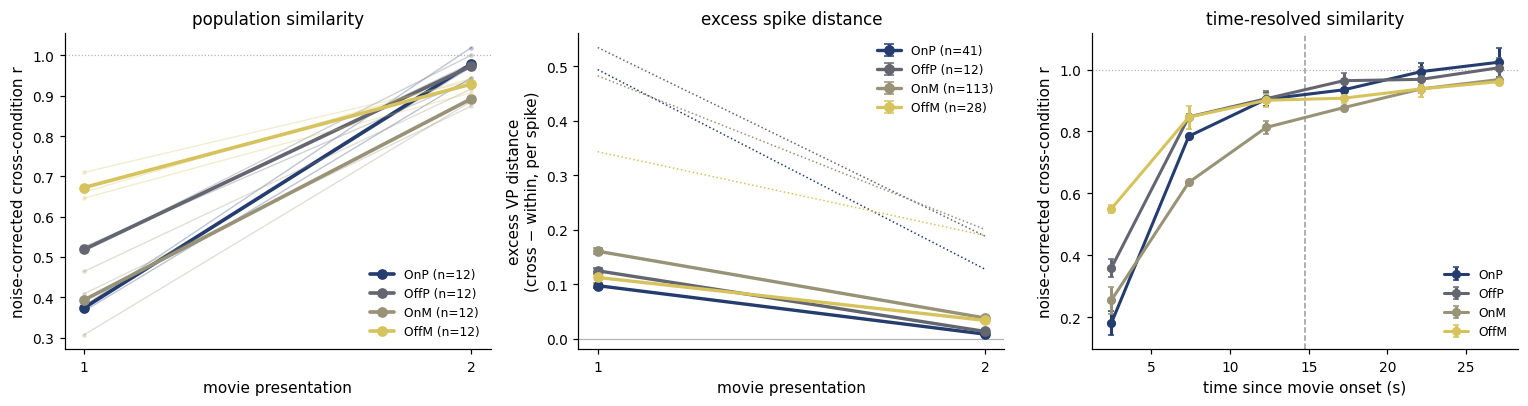

In [24]:
# Compact single-date figure saved beside this date's pickle and metadata.
EYE_DATE_FIG, axes = plt.subplots(1, 3, figsize = (14, 3.8))
ra.plot_population_similarity(SIM, cell_types = MAIN_TYPES, ax = axes[0],
                              title = 'population similarity')
ra.plot_excess_distance(DIST, cell_types = MAIN_TYPES, ax = axes[1],
                        title = 'excess spike distance')
ra.plot_time_resolved_similarity(TRAJ, cell_types = MAIN_TYPES, ax = axes[2],
                                 title = 'time-resolved similarity')
EYE_DATE_FIG.tight_layout()

EYE_DATE_FIGURES = {'key_analysis': EYE_DATE_FIG}
_eye_optional_static = {
    'cell_qc_mosaic': 'EYE_QC_MOSAIC_FIG',
    'cycle_period_scan': 'EYE_CYCLE_PERIOD_FIG',
    'recorded_eye_trajectory': 'EYE_TRAJECTORY_FIG',
    'response_timescale': 'EYE_TIMESCALE_FIG',
    'population_response_matrices': 'EYE_POPULATION_MATRICES_FIG',
    'similarity_population_vs_cell': 'EYE_SIMILARITY_POP_VS_CELL_FIG',
    'similarity_normalization': 'EYE_SIMILARITY_NORMALIZATION_FIG',
    'spike_distance': 'EYE_SPIKE_DISTANCE_FIG',
    'time_resolved_similarity': 'EYE_TIME_RESOLVED_FIG',
    'OnM_vs_OnP_recovery': 'EYE_RECOVERY_FIG',
    'sorting_qc_summary': 'SORT_QC_SUMMARY_FIG',
}
_eye_skipped_figures = []
for plot_name, variable_name in _eye_optional_static.items():
    figure = globals().get(variable_name)
    if figure is not None and hasattr(figure, 'savefig'):
        EYE_DATE_FIGURES[plot_name] = figure
    else:
        _eye_skipped_figures.append(variable_name)
for prefix, variable_name in {
        'cell_qc_raster': 'EYE_QC_RASTER_FIGURES',
        'sorting_qc_detected_spikes_cell':
            'SORT_QC_DETECTED_SPIKE_FIGURES',
        'sorting_qc_cell': 'SORT_QC_CELL_FIGURES',
}.items():
    collection = globals().get(variable_name)
    if collection is None:
        _eye_skipped_figures.append(variable_name)
        continue
    for label, figure in collection.items():
        if figure is not None and hasattr(figure, 'savefig'):
            EYE_DATE_FIGURES[f'{prefix}_{label}'] = figure
print(f'Saving {len(EYE_DATE_FIGURES)} available date-level figures.')
if _eye_skipped_figures:
    print('Skipped unavailable figure sources: ' +
          ', '.join(_eye_skipped_figures))

eye_date_bundle = ra.save_eye_movement_results(
    EXP_NAME,
    output_root = EYE_OUTPUT_ROOT,
    similarity = SIM,
    cycle_interaction = CYCLE,
    spike_distance = DIST,
    trajectory = TRAJ,
    cell_type_recovery = EYE_CELL_TYPE_RECOVERY,
    cell_type_fits = EYE_CELL_TYPE_FITS,
    cell_type_comparison = EYE_CELL_TYPE_COMPARISON,
    response_timescale_by_type = TIMESCALE.by_type.reset_index(),
    response_timescale_per_cell = TIMESCALE.per_cell,
    extra_analysis = {
        'similarity_common_timescale': SIM_COMMON,
        'sorting_qc_summary': SORT_QC_TABLE.copy(),
        'sorting_qc_events': SORT_QC_EVENTS,
    },
    metadata = {
        'datafile_name': DATAFILE_NAME,
        'analysis_chunk': ANALYSIS_CHUNK,
        'condition_keys': CONDITION_KEYS,
        'good_cells': len(GOOD_CELLS),
        'sigma_ms': SIGMA_MS,
        'vp_cost_per_s': VP_COST,
        'repeat_timing': TIMING,
        'saved_cell_types': EYE_CELL_TYPES_TO_SAVE,
        'primary_cell_type_comparison': EYE_COMPARE_TYPES,
        'cell_type_counts': (REPEAT.cells.groupby('cell_type')['cell_id']
                             .nunique().astype(int).to_dict()),
        'recovery_metric': 'rho_corrected',
        'recovery_normalization': 'first=0; mean(last 2 sections)=1',
        'recovery_fit_skip_first_s': EYE_RECOVERY_SKIP_FIRST_S,
        'sorting_qc': {
            'ran': bool(not SORT_QC_TABLE.empty),
            'epoch_index': SORT_QC_EPOCH,
            'window_s': SORT_QC_WINDOW_S,
            'n_cells_per_type': SORT_QC_N_PER_TYPE,
            'min_empirical_spikes': SORT_QC_MIN_SPIKES,
            'sampled_cell_ids': (SORT_QC_TABLE.cell_id.astype(int).tolist()
                                 if 'cell_id' in SORT_QC_TABLE else []),
        },
    },
    figures = EYE_DATE_FIGURES,
)
plt.show()

### Cross-date eye-movement summary

Reload all saved date bundles, draw each retina faintly, and overlay the equally weighted date mean ± SEM. The primary plot shows the normalized OnM/OnP recovery curves and paired `tau`/`t50`; the broader three-panel plot retains every saved cell type and supporting endpoint. Saving writes all combined tables, date reductions, JSON provenance, and both plots together.

In [ ]:
ALL_EYE_RESULTS = ra.load_eye_movement_many(
    output_root = EYE_OUTPUT_ROOT)
EYE_CROSS_FIG, axes = ra.plot_eye_movement_across_dates(
    ALL_EYE_RESULTS, cell_types = MAIN_TYPES)
EYE_CROSS_CELLTYPE_FIG, axes = ra.plot_eye_movement_cell_type_across_dates(
    ALL_EYE_RESULTS['cell_type_recovery'],
    ALL_EYE_RESULTS['cell_type_recovery_fits'],
    cell_types = EYE_COMPARE_TYPES)
eye_summary_bundle = ra.save_eye_movement_cross_date_summary(
    ALL_EYE_RESULTS,
    output_root = EYE_OUTPUT_ROOT,
    metadata = {
        'primary_cell_type_comparison': EYE_COMPARE_TYPES,
        'recovery_normalization': 'first=0; mean(last 2 sections)=1',
    },
    figures = {
        'cross_date_key_analysis': EYE_CROSS_FIG,
        'cross_date_OnM_vs_OnP_recovery': EYE_CROSS_CELLTYPE_FIG,
    },
)
print(f'combined dates: '
      f'{ALL_EYE_RESULTS["similarity"]["exp_name"].nunique()}')
display(ra.saved_analysis_stats(
    'emtraj', output_root = EYE_OUTPUT_ROOT))
display(ALL_EYE_RESULTS['cell_type_recovery_comparison'].round(3))
plt.show()


---

# Appendix — the archive and single-cell workflow

Everything below is the previous version of this notebook, kept as it was: protocol QC written to `qc.csv`, the visual-QC GUI, the per-cell PNG archive for one date and for many, the sorting-QC panels, the offline HDF5 store, and the per-date and cross-date single-cell analyses in `retinanalysis.protocols.eye_movement_alt_bg`.

It is still the way to build an archive or an `offline.h5`, and §A2's QC is a different and more conservative gate than §4's. **Its section numbers are the old ones** — the `§4`, `§7`, `§10` in these cells' comments refer to each other, not to the sections above. Cells here read `pipeline`, `EXP_NAME` and `DATAFILE_NAME` from §1, so run §1 first; the old §1–§3 that found a dataset and built the pipeline are gone, because `demos/meaAnalysisMain.ipynb` is that notebook now.

## 4. Per-cell QC inside the protocol (`EyeMovementTrajectoryAlternatingBackground`)

A cell can pass classification on the noise chunk and still misbehave
inside a long protocol like this one — drift off, drop out for runs of
trials, or barely fire. `protocol_qc.block_qc_metrics()` returns a
per-cell metrics DataFrame; `filter_cells_by_qc()` adds a boolean
`passes` column.

**Output**: `<OUTPUT_DIR>/<exp>/<protocol_subdir>/qc.csv` — the **initial
good/bad tagging** for every cell. §5 (visual QC), §6/§9 (archives)
and §10 (offline store) all honor it.

### Two automated gates do most of the work

- **Adaptive firing rate.** A cell passes when ≥ `min_frac_epochs_above_rate`
  (default **80%**) of its epochs hit the rate threshold
  (`min_rate_hz × epoch_duration_s`, default 1 Hz). Scales with epoch
  length so the same defaults work across 5 s, 30 s, and 60 s
  protocols (typical for this protocol is ~60 s).
- **Silent-epoch survival.** A cell passes when ≥
  `min_frac_non_silent_epochs` (default **2/3**) of its epochs have
  ≥1 spike — "drop the silent epochs and keep the cell if at least
  two-thirds of its trials survive" without actually dropping epochs.

### Tuning

`OVERWRITE_QC = False` by default: a prior `qc.csv` is loaded as-is.
Flip to `True` after editing `MIN_RATE_HZ` / `MIN_FRAC_EPOCHS` /
`MIN_FRAC_NON_SILENT` to recompute and overwrite. The summary printed
at the bottom reports pass rate per cell type and the first few failing
cells with their gate scores — quick way to see whether the gates are
biased against a specific type.

### Other reportable metrics (off by default; gate by setting thresholds)

`min_count_per_epoch`, `cv_count`, `fano`, `silent_trial_frac`,
`silent_run_max`, `drift_score`, `reliability_r` (split-half PSTH; off
by default for mixed-condition protocols like this one).

In [ ]:
# §4 — Protocol QC. ra.load_or_compute_protocol_qc reads qc.csv if it
# exists (overwrite=False), otherwise runs block_qc_metrics +
# filter_cells_by_qc and writes it. Same protocol_subdir resolution
# as §6/§9, so paths stay in sync.

# ---- USER INPUT --------------------------------------------------------
OVERWRITE_QC = True               # True → recompute even when qc.csv exists
MIN_RATE_HZ = 1                    # firing-rate floor in spikes/s
MIN_FRAC_EPOCHS = 0.8              # fraction of epochs that must meet that rate
MIN_FRAC_NON_SILENT = 2.0 / 3.0    # cell kept iff ≥ this fraction of epochs has ≥1 spike
# ------------------------------------------------------------------------

qc = ra.load_or_compute_protocol_qc(
    response_block, exp_name,
    protocol_subdir=protocol_subdir,
    append_datafile_to_subdir=append_datafile_to_subdir,
    datafile_name=datafile_name,
    overwrite=OVERWRITE_QC,
    min_rate_hz=MIN_RATE_HZ,
    min_frac_epochs=MIN_FRAC_EPOCHS,
    min_frac_non_silent=MIN_FRAC_NON_SILENT,
    verbose=True,
)

# Show the most informative failures.
fails = qc[~qc.passes].sort_values('frac_non_silent_epochs')
print(f'\nFirst few failing cells ({len(fails)} total):')
display(fails[['cell_id', 'cell_type', 'n_epochs', 'mean_rate_hz',
               'frac_epochs_above_rate', 'frac_non_silent_epochs',
               'silent_run_max', 'drift_score']].head().round(2))


## 5. Visual QC (optional) — click through each cell, tag good/bad

**This step is optional.** §4 wrote an automated QC pass/fail to
`qc.csv`. Use this section when you want to **further restrict** the
archive by eyeballing each cell's raster + PSTH.

### Iterative workflow

1. First time through, **skip this section** (no PNGs exist yet) and
   run §6 / §9 to build the initial archive.
2. Come back here once PNGs are on disk — `ra.browse_cells_qc(exp_name)`
   opens an ipywidgets panel that pages through cells (raster left,
   PSTH right) with `Good` / `Bad` / `Prev` / `Next` buttons. Each
   click upserts a row in
   `<OUTPUT_DIR>/<exp>/<protocol_subdir>/visual_qc.csv` — the session
   is resumable.
3. Re-run §6 / §9. They auto-detect `visual_qc.csv` and restrict the
   per-cell PNG render to cells tagged `good`. `cell_match.csv` is
   left comprehensive so downstream EI joins still see the full
   population.

### Downstream selection (no change needed)

```python
cells = ra.select_good_cells()   # uses visual_qc.csv if present, else QC-pass set
```

### Invariant

`visual_qc.csv` is **written only by this GUI**. `analyze_experiment`,
`save_per_cell_plots`, `save_cell_match`, and `save_protocol_qc` are
all read-only with respect to it (audited in
`tests/test_visual_qc_invariant.py`).

Requirements: `ipywidgets` (already in the `retinanalysis` kernel).

In [ ]:
# Launch the per-cell GUI for the date picked in §2. If no PNGs exist
# yet, the widget prints a message and returns — run §6 (single date) or
# §9 (batch) first to build the archive, then come back here to tag.
#
# `datafile_name` + `protocol_subdir` from §2 select the same archive
# subdir §6 / §9 wrote into (e.g. eye_movement_alt_bg_data018/).
ra.browse_cells_qc(
    exp_name,
    datafile_name=datafile_name,
    protocol_subdir=protocol_subdir,
)


## 6. Archive the picked date (single date)

Run `ra.analyze_experiment(exp_name, datafile_name)` to write the
**full per-cell PNG archive** for the date selected in §2. Output goes
to `<OUTPUT_DIR>/<exp>/<protocol_subdir>/`:

| file | what it is |
|---|---|
| `mosaic.png` | composite: STA mosaic + temporal-filter + ISI rows |
| `index.csv` | one row per archived cell (`cell_id`, `cell_type`, …) |
| `cell_match.csv` | EI-match diagnostics per cell — kept comprehensive |
| `cells/<celltype>/cell_<id>_raster.png` | per-cell raster, condition-colored |
| `cells/<celltype>/cell_<id>_psth.png` | per-cell PSTH, condition-colored |

### Visual-QC integration is automatic

If `visual_qc.csv` exists for this experiment (from §5), the call
below **restricts the per-cell PNG step to cells tagged `good`** — no
extra flags needed. Otherwise it falls back to every cell that passed
§4's automated QC.

### Re-archiving prunes stale PNGs

`prune_stale=True` (default): any `cells/.../cell_<id>_*.png` whose
`cell_id` is *not* in the kept set (QC-pass ∩ visual-QC `good`) is
deleted on re-run. So tagging cells `bad` in §5 and re-running this
cell removes their PNGs from disk. Non-canonical files (e.g. a
`README`) are not touched.

### Pitfall: same-protocol-twice-in-one-day

If a date has **two datafiles of the same protocol**, the default
`protocol_subdir` (the short name, e.g. `eye_movement_alt_bg`) is the
same for both runs — the second would overwrite the first. Set
`append_datafile_to_subdir=True` (or pass an explicit
`protocol_subdir`) to disambiguate.

### Conditions used for raster + PSTH coloring

Auto-detected from this protocol's registry entry; for
`EyeMovementTrajectoryAlternatingBackground` it is
`currentBackgroundScale` (the low/high background pairing).

In [ ]:
# Full archive for the date picked in §2. analyze_experiment now reads
# visual_qc.csv on its own (respect_visual_qc=True by default) and
# restricts the per-cell PNG step to cells tagged 'good' when the file
# exists — no extra notebook glue needed. overwrite=True regenerates
# every targeted PNG.

# The protocol_subdir / append_datafile_to_subdir defaults are set in §2
# so the same convention applies to §4 QC and §7/§8 sorting QC as well.

result = ra.analyze_experiment(
    exp_name,
    datafile_name=datafile_name,
    overwrite=True,
    fit_calibration=False,
    n_jobs=-1,
    verbose=True,
    protocol_subdir=protocol_subdir,
    append_datafile_to_subdir=append_datafile_to_subdir,
)
print(f'\nDone: {result["exp_name"]} / {result["datafile_name"]} — '
      f'QC-pass pool: {result["n_cells_passed_qc"]}/{result["n_cells_total"]}')
print(f'  output_dir: {result["output_dir"]}')


## 7. Spike-sorting QC — static PNGs (batch / remote review)

PSTH + raster confirm that spike *times* are consistent with the
stimulus; they don't tell you whether **the spikes were assigned to
the right cell** in the first place. This cell samples a few cells
(QC-pass ∩ visual-QC `good`) per type and writes one **multi-row PNG
per cell**: each row is one full epoch (raster strip on top, 300-Hz
high-pass-filtered raw trace below, red dots at the cell's spike
times, snapped to the local trough in ±2 ms).

A clean sort: red dots land on visible spike waveforms in the trace.
A merge: extra waveforms in the trace with no red dot, *or* red dots
on flat baseline (template hits that aren't real spikes).

### Output

`<OUTPUT_DIR>/<exp>/<protocol_subdir>/sorting_qc_<protocol_short>_<datafile>/cell_proto<XXXX>_noise<YYYY>_<celltype>_sorting_qc.png`

The folder name stamps both the protocol short name and the datafile
so multiple runs of `EyeMovementTrajectoryAlternatingBackground` on
one date don't collide.

### When to prefer this over §8

- **Batch review of many cells / dates**: PNGs are reviewable offline
  and shareable.
- **Slow or metered connection**: a 4-epoch sample is heavy
  (~3.6 GB read from raw `.bin` per cell on a typical 60-s epoch). §8
  loads only a sub-window per click.

### When to prefer §8

- **Spot checks** of one cell at a time with interactive zoom.
- **Remote NAS sessions** — see the bandwidth chip in §8.

In [ ]:
# §7 — Sorting QC via raw traces, saved to disk as high-DPI PNGs.
# Samples from QC-pass ∩ visual-QC 'good' cells per type and writes one PNG
# per cell to <OUTPUT>/<exp>/<protocol_subdir>/sorting_qc_<protocol>_<datafile>/.
# Each PNG has N_EPOCHS full-width rows; every row = thin raster strip +
# 300 Hz HP-filtered trace with red marks at the cell's spike times.

CELL_TYPES         = ['OnP', 'OnM']    # which types to sample
N_CELLS_PER_TYPE   = 3                  # cells per type
N_EPOCHS           = 4                  # full epochs to show per cell
SAMPLE_STRATEGY    = 'random'           # 'random' (default) or 'top_rate'
RANDOM_SEED        = None               # int for reproducible sampling; None = fresh
DPI                = 250                # 200–300 is good for visual inspection
OVERWRITE_QC_PNGS  = True               # re-render existing PNGs

sample_df, png_paths = ra.sample_and_plot_sorting_qc(
    response_block,
    protocol_subdir=protocol_subdir if 'protocol_subdir' in dir() else None,
    append_datafile_to_subdir=(append_datafile_to_subdir
                                if 'append_datafile_to_subdir' in dir() else False),
    cell_types=CELL_TYPES,
    n_cells_per_type=N_CELLS_PER_TYPE,
    n_epochs=N_EPOCHS,
    sample_strategy=SAMPLE_STRATEGY,
    random_seed=RANDOM_SEED,
    dpi=DPI,
    overwrite=OVERWRITE_QC_PNGS,
)
print(f'\n→ wrote {len(png_paths)} PNG(s); open them with the system viewer.')


## 8. Interactive sorting-QC GUI (`ra.sorting_qc_gui`)

Notebook ipywidgets panel — same diagnostic as §7 but **one click =
one window**, on demand. Designed for remote-NAS sessions where
loading a full epoch (~1 GB at 20 kHz × 512-electrode 12-bit) is
wasteful.

### Controls (top to bottom)

| widget | what it does |
|---|---|
| **Cell** | dropdown over `QC-pass ∩ visual-QC good` for cell types `OnP`, `OnM` (extendable). Labels show cell type, protocol cell id, matched noise id, mean rate. |
| **Epoch** | which epoch of `EyeMovementTrajectoryAlternatingBackground` to load (~60 s each in this protocol). |
| **Electrode** | 1st / 2nd / 3rd top-amplitude electrode for the chosen cell's EI. Switching rank is **free** (`rt.data` already holds all 512 electrodes for the cached window). |
| **Window (s)** | slider + `start (s)` / `end (s)` text boxes (synced). Type for precise values; the estimated MB on the wire is shown next to the slider. |
| **Appearance** (accordion) | trace color / line width, spike color / marker size, HP cutoff (Hz), manual y-range (also acts as a y-axis scrollbar: drag the bar between handles to pan), figure width and height. **All re-render from cache with zero I/O.** |
| **View (X)** row | ⊕ zoom in · ⊖ zoom out · ◀ pan · pan ▶ — shrink/expand or shift the window by half its width. Zoom-in stays **inside the loaded data → free**; pan past the loaded window re-fetches. |
| **View (Y)** row | ⊕ zoom y · ⊖ zoom y · ▲ pan y · pan y ▼ · y auto-fit — adjust the voltage axis range. Pressing any of these auto-disables `y-axis auto`. **All free** — pure re-render. |
| **Load raw trace** | the main button that may trigger NAS bytes. Idempotent: re-clicking the same (epoch, window) is served from cache, and any sub-range of the loaded window also hits the cache. |
| **Overlay detected spikes** | toggle red dots + raster strip. Zero I/O. |
| **Bandwidth chip** | green = local mount (SSD, USB, …), amber = network mount (SMB / NFS / AFP). Ticks up only on real reads; reset button zeroes it. *Caveat*: macOS page-cache means this is an **upper bound** on wire bytes. |

### What re-fetches over the network vs what is free

| action | re-reads file? |
|---|---|
| First Load click for a new (cell, epoch, window) | **yes** |
| Same Load click again | no (idempotency guard) |
| Switch electrode rank | no |
| Toggle spike overlay | no |
| Any appearance widget (color, lw, HP cutoff, fig height, …) | no |
| **View (X)** ⊕ zoom in (or smaller window inside the loaded one) | no — served from cache |
| **View (X)** ⊖ zoom out / ◀ pan / pan ▶ past the loaded window | **yes** for the new bytes only |
| **View (Y)** any button (zoom / pan / reset) | no — pure re-render |

### Vector output

Plots are **always vector SVG** — browser pinch / Ctrl-+ stays crisp
at any zoom level. For a *native* pan / zoom-rectangle toolbar inside
the figure (with a draggable selection rectangle), `pip install
ipympl` then add `%matplotlib widget` at the top of the notebook;
the GUI surfaces a one-line hint when ipympl is absent.

In [ ]:
from IPython.display import display

# Launches an ipywidgets panel for the pipeline built in §3.
# Pick cell → epoch → top-3 electrode → window (slider or
# FloatText) → 'Load raw trace'. Appearance accordion exposes
# trace/marker style and HP-cutoff frequency. The bandwidth
# meter at the bottom tracks cumulative MB read from disk.
#
# protocol_subdir / append_datafile_to_subdir come from §2 so the GUI
# reads qc.csv from the same folder §4/§6/§9 wrote it into
# (e.g. eye_movement_alt_bg_data030/qc.csv).
display(ra.sorting_qc_gui(
    response_block,
    protocol_subdir=protocol_subdir if 'protocol_subdir' in dir() else None,
    append_datafile_to_subdir=(append_datafile_to_subdir
                                if 'append_datafile_to_subdir' in dir() else False),
))

## 9. Run the archive for one or many dates (standalone)

**Self-contained section** — run cell 1 (imports), then jump here.
`ra.analyze_experiments(dates, protocol_search=...)` packages every
step the earlier cells did manually into a single call per date:
`ss_version` + typing file + datafile auto-detect, pipeline build,
optional rig calibration, type normalization, QC, composite
`mosaic.png` (with temporal-filter + ISI rows), and per-cell
`cell_<id>_raster.png` + `cell_<id>_psth.png`.

### Defaults assume `EyeMovementTrajectoryAlternatingBackground`

`PROTOCOL_SEARCH = "AlternatingBackground"` substring-matches the full
Java class name. Change it to run the same archive over a different
protocol family — but condition coloring and QC thresholds may need
tuning for that protocol.

### Visual-QC integration

For any date that already has a `visual_qc.csv` in its archive folder,
the batch driver restricts that date's per-cell PNG step to cells
tagged `good`. Pass `respect_visual_qc=False` to override.

### Save toggle

`SAVE_FIGURES = True` ⇒ render and **overwrite** all PNGs.
`SAVE_FIGURES = False` ⇒ list the batch only and stop. The user
prefers this explicit gate over an auto-detect "does the PNG exist?"
check — don't re-introduce implicit skipping.

### Failure handling

`on_error="log"` so one bad date is recorded in the returned summary
DataFrame instead of aborting the batch. `n_jobs=-1` uses every CPU
core for per-cell PNG rendering.

In [ ]:
# Section 9 is SELF-CONTAINED — you only need cell 1 (imports) to run it.
# It will query the protocol registry on its own and dispatch the archive
# pipeline over every experiment found, in parallel.

# ---- USER INPUT --------------------------------------------------------
# Yes/no: should we (re)save figures for every cell?
#   True  → render and OVERWRITE all PNGs (use this to refresh stale plots).
#           Per-date visual_qc.csv (if present) restricts the per-cell
#           PNG step to cells tagged 'good'.
#   False → skip the archive step entirely (just list the batch and stop).
SAVE_FIGURES = True
# ------------------------------------------------------------------------

PROTOCOL_SEARCH = 'AlternatingBackground'   # substring matched against protocol names

# Build the date list from the protocol registry, keeping only experiments
# whose sort output is present on disk.
_exp_search = ra.find_available_datasets(PROTOCOL_SEARCH)
batch_dates = _exp_search['exp_name'].unique().tolist()

# Subset variants — uncomment / adapt as needed:
# batch_dates = ['20220823C', '20221123C', '20230502C']                                            # hand-pick
# batch_dates = _exp_search.query("exp_name >= '20230101C'")['exp_name'].unique().tolist()        # by date
# batch_dates = _exp_search.query('NDF == 2.0')['exp_name'].unique().tolist()                     # by NDF

print(f'Batch run over {len(batch_dates)} dates: {batch_dates}')
print(f'SAVE_FIGURES = {SAVE_FIGURES}  '
      f'({"overwrite all PNGs" if SAVE_FIGURES else "skip archive step"})')

if not SAVE_FIGURES:
    print('SAVE_FIGURES is False — not calling ra.analyze_experiments. '
          'Set SAVE_FIGURES = True above to (re)render PNGs.')
else:
    results = ra.analyze_experiments(
        batch_dates,
        protocol_search=PROTOCOL_SEARCH,    # resolves datafile per date
        fit_calibration=False,              # True on first pass to seed calibrations
        overwrite=True,                     # resave every PNG (driven by SAVE_FIGURES)
        n_jobs=-1,                          # all CPU cores for per-cell rendering
        on_error='log',                     # keep going past per-date failures
        respect_visual_qc=True,             # restrict to good-tagged cells when present
        verbose=True,
    )
    display(ra.summarize_batch_results(results))


## 10. Offline data store (`offline.h5`) — build once, reload fast

After §5/§6 leaves a curated visual-QC set, `ra.load_or_build_offline`
packages everything an analysis needs — metadata, condition table,
per-cell spike times, smoothed PSTHs, STA fit, EI summary — into a
single HDF5 at
`<OUTPUT_DIR>/<exp>/eye_movement_alt_bg/offline.h5`. Subsequent
sessions just **load** the file; no DataJoint, no SSD pipeline rebuild.

- **First call**: builds the pipeline → runs §4 QC → intersects with
  `visual_qc.csv` (good cells only) → writes `offline.h5`. ~1–2 min/date.
- **Re-runs**: `ra.load_offline_data(exp)` returns an `OfflineDataset`
  in <1 s. Pass `overwrite=True` to rebuild from source.
- **Cross-date**: `ra.load_offline_many()` → `{exp_name: OfflineDataset}`
  for every date that has `offline.h5`.

### `OfflineDataset` API

| attribute / method | what it is |
|---|---|
| `ds.meta`, `ds.timing` | scalars (exp id, datafile, ndf, preTime/stimTime/sample_rate) |
| `ds.epochs` | DataFrame, one row per epoch (`currentImageName`, `currentBackgroundScale`, …) |
| `ds.cells` | DataFrame, one row per saved cell (cell_type, STA fit, EI stats) |
| `ds.spike_times(cell_id)` | list of arrays (ms), one per epoch |
| `ds.psth_matrix(cell_id)` | `(n_epochs, n_bins)` Hz, Gaussian-smoothed |
| `ds.psth_time_ms()` | shared bin-center time axis |

### Why HDF5 and not Parquet/Pickle

Ragged per-epoch spike-time arrays + a regular `(n_epochs, n_bins)`
PSTH matrix coexist naturally in HDF5 groups. Reload is ~0.2 s and
the file is portable across machines.

In [ ]:
# §10 — Build / load the offline store for one experiment.
# First call: 1–2 min; subsequent calls: <1 s.

EXP = '20221123C'
PROTOCOL = 'eye_movement_alt_bg'

ds = ra.load_or_build_offline(
    EXP, protocol=PROTOCOL,
    protocol_search='AlternatingBackground',
    overwrite=False, verbose=True,
)
print(ds)
print('cell types:', ds.cell_types())
display(ds.epochs.head())
display(ds.cells.head())


## 11. Offline analyses (`retinanalysis.protocols.eye_movement_alt_bg`)

Each analysis takes the `OfflineDataset` from §10 and returns a
DataFrame (or dict for population metrics). Results are saved next to
`offline.h5` so cross-date pooling in §12 is a single `pd.concat`.

| function | what it computes | output |
|---|---|---|
| `analyze_offline` | per-(cell-type × condition) mean PSTHs | dict (in-memory) |
| `spike_distance_analysis` | Victor-Purpura distance over a 5-s window per trial. Reports within-condition mean (variability inside a condition) and across-condition mean; `d_diff = d_across - d_within_avg > 0` means the condition modulates the response. | DataFrame + `spike_distance.csv` |
| `movie_repeat_analysis` | splits `stimTime` into cycle-1 vs cycle-2 (drop first second). Reports per (cell, condition): correlation, RMSE, mean-rate ratio (adaptation index), and optional per-trial VP distance. | DataFrame + `movie_repeat.csv` |
| `population_time_scale_metrics` | time-resolved population-vector divergence between the two `currentBackgroundScale` levels per cell type (Cohen's d, Euclidean / cosine distance, cumulative |Δrate|, per-bin Mann-Whitney AUC). | dict (in-memory) |

These defaults are **tuned for `EyeMovementTrajectoryAlternatingBackground`**:
- Movie cycle = one full eye-movement trajectory loop. The nominal value is
  `stimTime/2` = 15 s and it is **wrong on this rig** — §5 above measures
  14.922 s, starting at 29.843 s rather than at `preTime`. `movie_repeat_analysis`
  still defaults to the nominal numbers because the offline store carries only
  the protocol's timing, so the cell below passes §5's measured ones; folded at
  15.000 s the two cycles are 78 ms out of register and `corr_cycle12` drops for
  that reason alone.
- Condition keys = `(currentImageName, currentBackgroundScale)`.
- Population comparison axis = `currentBackgroundScale`.

For a different protocol, write a new analyzer module under
`retinanalysis/protocols/<protocol_name>/` and call it from a
protocol-specific notebook.

In [ ]:
# §11a — Average PSTH by (cell type × condition). Offline = no DJ needed.
from retinanalysis.protocols import eye_movement_alt_bg as ema

r = ema.analyze_offline(ds, minimum_n=3)
print(f'cell types: {r["cell_types"]}')
print(f'{len(r["conditions"])} conditions, {len(r["time_ms"])} time bins')

ema.plot_psth_by_condition(r, show_individual_cells=False)


In [ ]:
# §11b — Movie-repeat comparison: cycle 1 vs cycle 2, drop the first second.
# The cycle and the movie onset come from §5, measured off the recorded frames.
# The nominal 15.000 s / 30.000 s misaligns the two cycles by 78 ms.
_timing = globals().get('TIMING')
CYCLE_SEC      = _timing['cycle_ms'] / 1000 if _timing else 15.0
MOVIE_ONSET_MS = _timing['onset_ms'] if _timing else None
print(f'folding at {CYCLE_SEC:.3f} s from {MOVIE_ONSET_MS or "preTime"} ms')

# compute_vp=False keeps it fast (~30 s); enable for per-trial VP timing differences.
mr = ema.movie_repeat_analysis(
    ds, cycle_sec=CYCLE_SEC, movie_onset_ms=MOVIE_ONSET_MS, drop_first_sec=1.0,
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    compute_vp=False,
)
print(f'rows: {len(mr)}')
display(mr.groupby('cell_type')[['n_trials',
                                  'rate_cycle1_hz', 'rate_cycle2_hz',
                                  'rate_ratio',
                                  'corr_cycle12', 'rmse_cycle12_hz']]
          .median().round(3))

# Save to disk for cross-date pooling
ema.save_movie_repeat(mr, ds.exp_name)

In [ ]:
# §11c — Population time-scale metrics: two backgroundScale levels per cell type.
# Returns dict {cell_type: {cohens_d_mean, pop_euclid_dist, pop_cosine_dist, ...}}.

pm = ema.population_time_scale_metrics(
    ds, primary_key='currentBackgroundScale',
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    smooth_ms=100.0, minimum_n=3,
)
ema.plot_population_time_scale(pm, ds)


In [ ]:
# §11d — Spike-distance (Victor-Purpura) across backgroundScale, within image.
# Default pair_within=('currentImageName',): for each image, pair trials across
# the low vs high backgroundScale.  C-accelerated DP makes this fast — under 5s
# for ~170 cells × 5 images.
sd = ema.spike_distance_analysis(
    ds, window_sec=5.0, cost_per_sec=4.0,
    cell_types=['OnP', 'OffP', 'OnM', 'OffM'],
    pair_within=('currentImageName',),   # hold image constant, compare BG scale
    n_trials_cap=None,                    # use every trial — fast in C
)
print(f'rows: {len(sd)}; cells: {sd["cell_id"].nunique()}; '
      f'images: {sd["group_key"].nunique()}')

display(sd.groupby('cell_type')[['d_within_avg', 'd_across', 'd_diff']]
          .agg(['median', 'count']).round(2))

ema.save_spike_distance(sd, ds.exp_name)


## 12. Cross-date aggregation

Once every experiment has been through §10–§11 (each writes
`offline.h5`, `spike_distance.csv`, `movie_repeat.csv` to its own
folder), pooling across dates is just a `concat`.

| call | returns |
|---|---|
| `ra.load_offline_many()` | `{exp_name: OfflineDataset}` for every experiment with `offline.h5` on disk |
| `ema.aggregate_psth_across_dates(offlines)` | pooled per-cell mean PSTHs as one `(n_cells_total, n_bins)` matrix per `(cell_type, condition)` — pass to `ema.plot_psth_by_condition` |
| `ema.load_spike_distance_many()` | long-format DataFrame, `exp_name`-tagged |
| `ema.load_movie_repeat_many()` | long-format DataFrame, `exp_name`-tagged |

Adding a new date to the pool: run §10 (and §11 if you want the
spike-distance / movie-repeat CSVs) for that date, then re-run §12
unchanged — `load_*_many()` picks it up automatically.

In [ ]:
# §12 — Cross-date pooled analyses.
offlines = ra.load_offline_many()  # all dates with offline.h5
print(f'experiments loaded: {len(offlines)}')
for exp, ds_ in offlines.items():
    print(f'  {exp}: {len(ds_.cell_ids)} cells, types={ds_.cell_types()}')

# Pool PSTHs across dates
pooled = ema.aggregate_psth_across_dates(offlines, minimum_n=5)
print(f'\npooled types: {pooled["cell_types"]} from {pooled["n_dates"]} dates')
ema.plot_psth_by_condition(pooled, show_individual_cells=False)

# Pool spike-distance & movie-repeat CSVs
sd_all = ema.load_spike_distance_many()
mr_all = ema.load_movie_repeat_many()
print(f'\nspike_distance rows: {len(sd_all)} from '
      f'{sd_all["exp_name"].nunique() if not sd_all.empty else 0} dates')
print(f'movie_repeat rows: {len(mr_all)} from '
      f'{mr_all["exp_name"].nunique() if not mr_all.empty else 0} dates')

# Headline cross-date summaries
if not sd_all.empty:
    display(sd_all.groupby(['cell_type'])
                  [['d_within_avg', 'd_across', 'd_diff']]
                  .agg(['median', 'count']).round(2))
if not mr_all.empty:
    display(mr_all.groupby(['cell_type'])
                  [['rate_ratio', 'corr_cycle12', 'rmse_cycle12_hz']]
                  .agg(['median', 'count']).round(3))
